In [12]:
# Parameters
param1=1

In [13]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce



In [14]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [15]:
C = Config()

C.G = 0.5
C.sig_h_2 = None
# C.gpu_id=1
# C.seed = 1
C.linear_net = False
# C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.0001
C.L=5
C.print_progress = True
C.cyclic_corridors = False
C.length_corridors = [20]*1
# C.input_size = 100
C.max_move = 25
C.hidden_size = 250 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1000
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.scalar_actions = False
C.cyclic_corridors = True
# C.egocentric_movement = True
# C.lambda_reg = 0 # 1e-3
# C.B = 1
# C.bias_batch = 0
# C.label_noise = 0.0
# C.isotropic_noise = 0.
# C.whiten_data = True
# C.fixed_output = False
# C.split_actions = False
C.allow_backwards = True
# C.mask_states = [(3,)]

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

In [16]:
data_dict_l = []
for max_move in [1, C.length_corridors[0]//4, C.length_corridors[0]//2, C.length_corridors[0]]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)

X = data_dict['X']
y = data_dict['y']
corridor = data_dict['corridor']
loc_X = data_dict['loc_X']
loc_y = data_dict['loc_y']
action_taken = data_dict['action_taken']
hidden_states = data_dict['hidden_states']
loss_l = data_dict['loss_l']
accuracy_l = data_dict['accuracy_l']
outputs = data_dict['outputs']
hidden_l = data_dict['hidden_l']
initial_weights = data_dict['initial_weights']
final_weights = data_dict['final_weights']
state_dict_l = data_dict['state_dict_l']
C = data_dict['C']

print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
loc_y_corridor = loc_y + (corridor * max(loc_y + 1))
n_corridors = len(C.length_corridors)

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
h_np = hidden  # Convert to numpy array if hidden is a torch tensor

Number of samples: 60
Input dimension: 23
Output dimension: 20
Number of actions: 3

Sig_2 of last hidden: 2.1128552418758773e-07


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:11<00:00, 83.46it/s]


Number of samples: 220
Input dimension: 31
Output dimension: 20
Number of actions: 11

Sig_2 of last hidden: 2.4353002459065465e-07


100%|██████████| 1000/1000 [00:16<00:00, 59.73it/s]


Number of samples: 420
Input dimension: 41
Output dimension: 20
Number of actions: 21

Sig_2 of last hidden: 2.0107536613522825e-07


100%|██████████| 1000/1000 [00:19<00:00, 50.92it/s]


Number of samples: 820
Input dimension: 61
Output dimension: 20
Number of actions: 41

Sig_2 of last hidden: 2.3055585529618838e-07


100%|██████████| 1000/1000 [00:28<00:00, 34.85it/s]

1.2148719535874042e-05


In [17]:
X = X_np
y = y_np
labels = y.argmax(1)


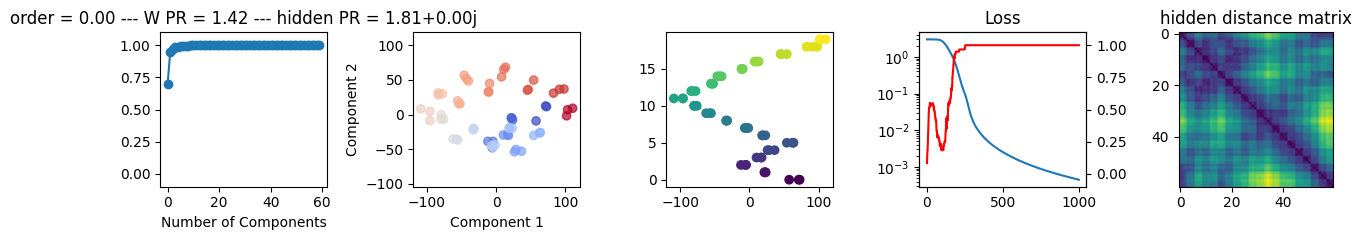

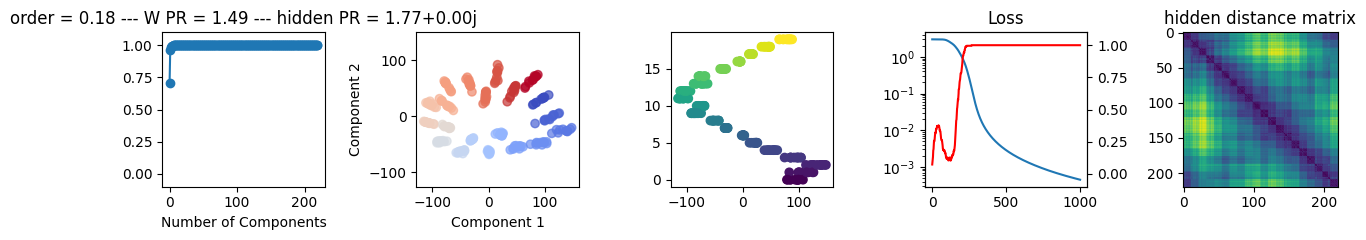

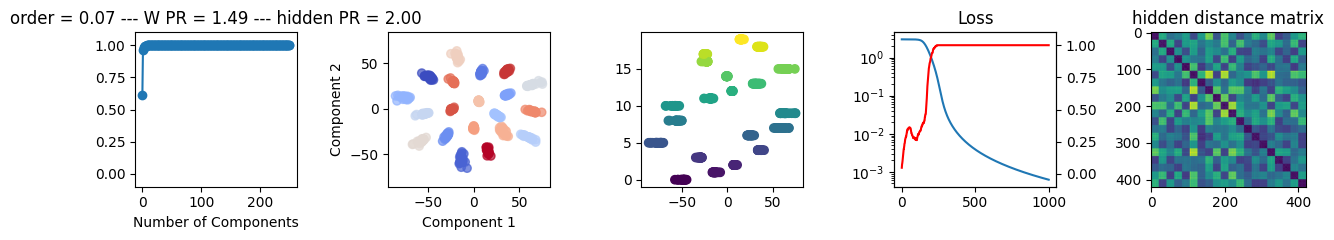

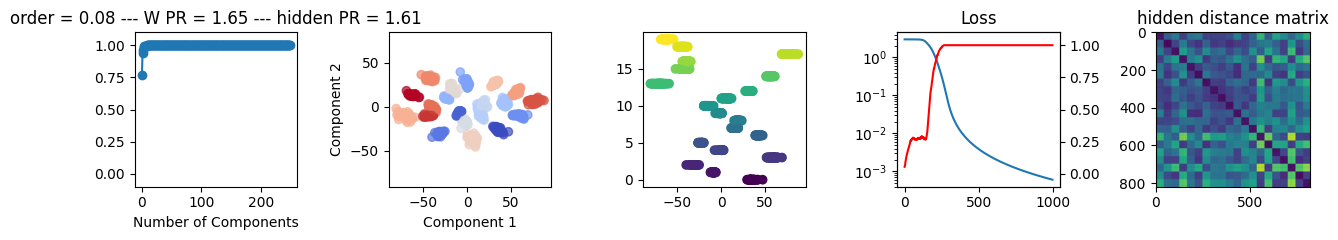

In [18]:
from utils_plot import plot_pca
for data_dict in data_dict_l:
    plot_pca(data_dict)

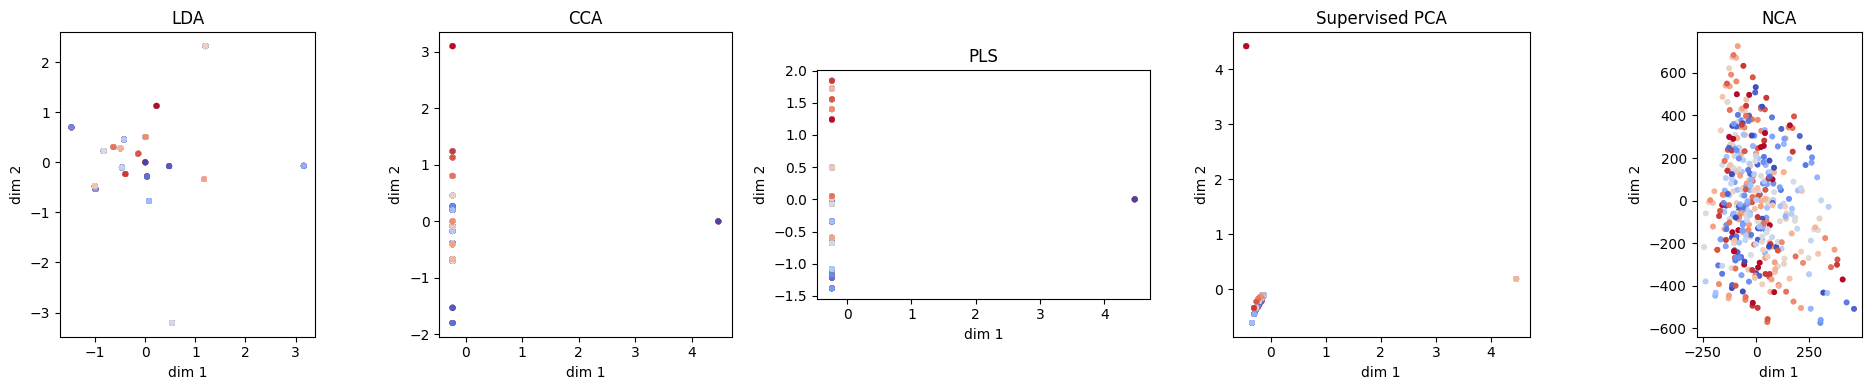

In [19]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import CCA, PLSRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline


def compute_supervised_projections(X, y_onehot):
    """
    X: (n_samples, n_features)
    y_onehot: (n_samples, n_classes) one-hot encoded targets

    Returns:
        dict: method_name -> 2D embedding (n_samples, 2)
    """
    X = np.asarray(X)
    y_onehot = np.asarray(y_onehot)

    # Class labels from one-hot targets
    y_class = np.argmax(y_onehot, axis=1)

    projections = {}

    # 1. Linear Discriminant Analysis (LDA)
    lda = LinearDiscriminantAnalysis(n_components=2)
    Z_lda = lda.fit_transform(X, y_class)
    projections["LDA"] = Z_lda

    # Standardize X for methods that like scaling
    scaler_x = StandardScaler()
    X_scaled = scaler_x.fit_transform(X)

    # 2. Canonical Correlation Analysis (CCA) between X and one-hot y
    cca = CCA(n_components=2)
    Z_cca, _ = cca.fit_transform(X_scaled, y_onehot)
    projections["CCA"] = Z_cca

    # 3. Partial Least Squares (PLS) Regression X -> y_onehot
    pls = PLSRegression(n_components=2)
    Z_pls, _ = pls.fit_transform(X_scaled, y_onehot)
    projections["PLS"] = Z_pls

    # 4. Supervised PCA: ANOVA F-score feature selection + PCA
    k = min(50, X.shape[1])  # number of features to keep before PCA
    spca = make_pipeline(
        StandardScaler(),
        SelectKBest(score_func=f_classif, k=k),
        PCA(n_components=2)
    )
    Z_spca = spca.fit_transform(X, y_class)
    projections["Supervised PCA"] = Z_spca

    # 5. Neighborhood Components Analysis (NCA): learns linear transform
    nca = make_pipeline(
        StandardScaler(),
        NeighborhoodComponentsAnalysis(n_components=2, random_state=0)
    )
    Z_nca = nca.fit_transform(X, y_class)
    projections["NCA"] = Z_nca

    return projections


def plot_supervised_projections(projections, labels, cmap="coolwarm"):
    """
    projections: dict of {name: (n_samples, 2)}
    labels: 1D array-like used for coloring points
    """
    labels = np.asarray(labels)
    if labels.ndim != 1:
        raise ValueError("labels must be a 1D array-like.")

    # Encode non-numeric labels if needed
    if labels.dtype.kind not in "if":  # not int/float
        le = LabelEncoder()
        numeric_labels = le.fit_transform(labels)
        label_names = le.classes_
    else:
        numeric_labels = labels
        label_names = None

    n_methods = len(projections)
    fig, axes = plt.subplots(1, n_methods, figsize=(4 * n_methods, 4), squeeze=False)
    axes = axes[0]  # 1 row

    for ax, (name, Z) in zip(axes, projections.items()):
        sc = ax.scatter(Z[:, 0], Z[:, 1],
                        c=numeric_labels,
                        s=10,
                        alpha=0.8,
                        cmap=cmap)
        ax.set_title(name)
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.set_aspect('equal')

    # Add legend if labels are categorical
    if label_names is not None:
        from matplotlib.lines import Line2D

        unique_vals = np.unique(numeric_labels)
        handles = [
            Line2D([0], [0],
                   marker="o",
                   linestyle="",
                   markerfacecolor=sc.cmap(sc.norm(u)),
                   label=str(label_names[u]))
            for u in unique_vals
        ]
        axes[-1].legend(handles=handles,
                        title="labels",
                        bbox_to_anchor=(1.05, 1),
                        loc="upper left")

    fig.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# Example usage (you already have X, y_onehot, labels in your code):
# -------------------------------------------------------------------
projections = compute_supervised_projections(X, y)
plot_supervised_projections(projections, labels)


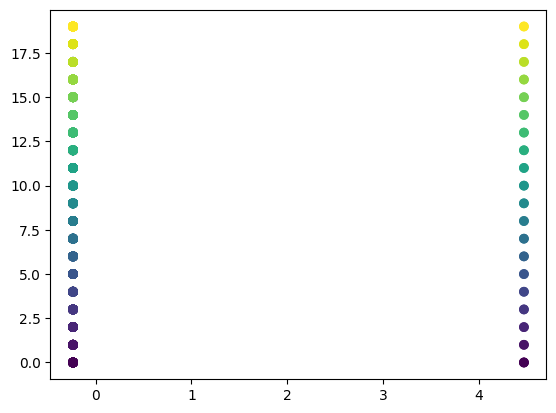

In [20]:

cca = CCA(n_components=2)
Z_cca, _ = cca.fit_transform(X, y)

plt.scatter(Z_cca[:, 0], y.argmax(1), c=labels, cmap='viridis')

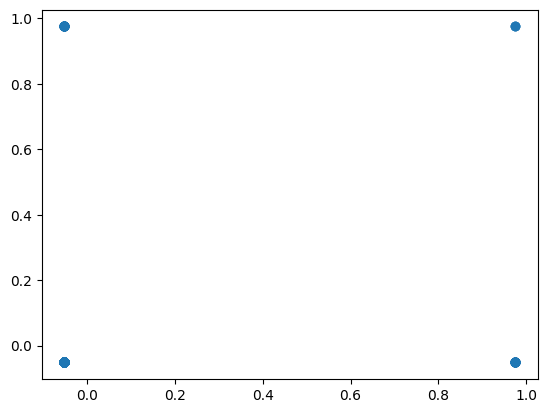

In [21]:
# plt.plot(y[y.argmax(1).argsort(),:]@cca.y_rotations_[:,0])
plt.scatter(X@cca.x_rotations_[:,0], y@cca.y_rotations_[:,0])

In [22]:
import numpy as np

def matrix_inverse_sqrt(Sigma, eps=1e-12):
    # Ensure symmetric
    Sigma = 0.5 * (Sigma + Sigma.T)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(Sigma)

    # Regularize small eigenvalues for numerical stability
    eigvals = np.clip(eigvals, eps, None)

    # Build Λ^{-1/2}
    D_inv_sqrt = np.diag(1.0 / np.sqrt(eigvals))

    # Σ^{-1/2} = Q Λ^{-1/2} Q^T
    Sigma_inv_sqrt = eigvecs @ D_inv_sqrt @ eigvecs.T
    return Sigma_inv_sqrt

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


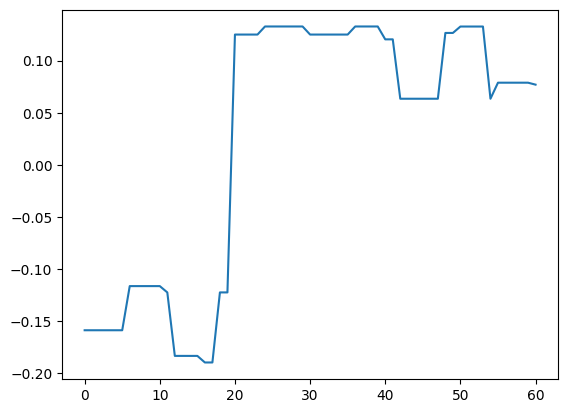

In [23]:
n = X.shape[0]
S_XX = X.T@X/n
S_XY = X.T@y/n
S_YY = y.T@y/n
S_YX = y.T@X/n

eig, eig_v = np.linalg.eig(np.linalg.inv(S_XX)@S_XY@np.linalg.inv(S_YY)@S_YX)
a = eig_v[:, eig.argmax()]
# print(a.shape)
plt.plot(a)

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


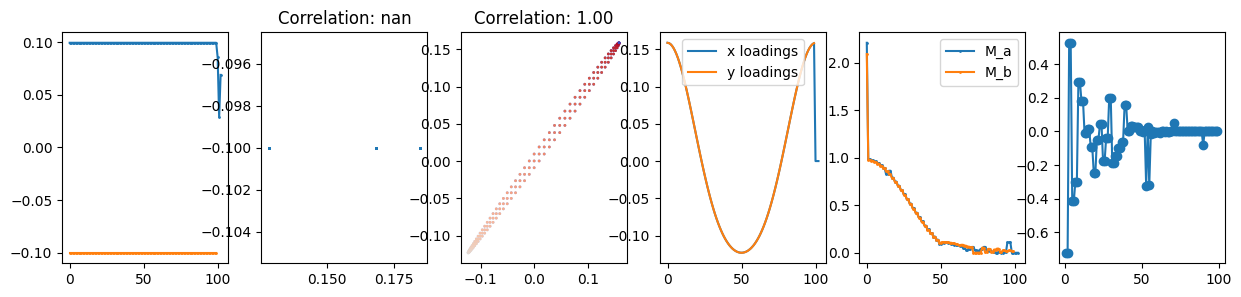

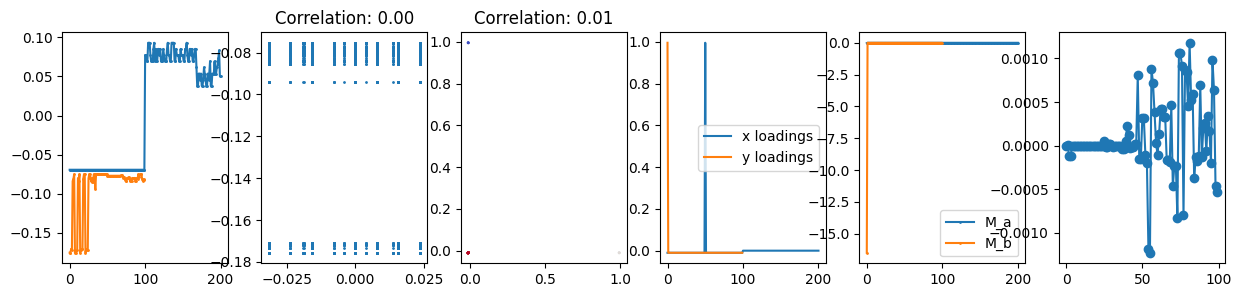

In [25]:
C.length_corridors = [100]
C.print_progress = False
for max_move in [1, C.length_corridors[0]//2]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    reps = 1
    noise = 0
    X = np.concatenate([X]*reps, axis=0)
    y = np.concatenate([y]*reps, axis=0)
    action_taken = np.concatenate([action_taken]*reps, axis=0)

    X += np.random.randn(*X.shape)*noise
    y += np.random.randn(*y.shape)*noise
    
    labels = y.argmax(1)
    cond = abs(action_taken) <= 1

    n = X.shape[0]
    S_XX = X.T@X/n
    S_XY = X.T@y/n
    S_YY = y.T@y/n
    S_YX = y.T@X/n

    mse = (y-X@np.linalg.pinv(X.T@X)@X.T@y).var()


    fig, axs = plt.subplots(1, 6, figsize=(15, 3))
    N = C.length_corridors[0]
    A = max_move
    # a = np.concatenate([np.arange(0,N), np.arange(-A,A+1)])
    # b = np.arange(0,N)
    M_a = np.linalg.pinv(S_XX)@S_XY@np.linalg.pinv(S_YY)@S_YX
    M_b = np.linalg.pinv(S_YY)@S_YX@np.linalg.pinv(S_XX)@S_XY
    a = np.linalg.eig(M_a)[1][:,[0]].real
    b = np.linalg.eig(M_b)[1][:,[0]].real
    X_proj = X@a
    y_proj = y@b
    U, S, V = np.linalg.svd(S_XY)
    # fig.suptitle(f'mse: {mse:.2f}')
    axs[0].plot(a, marker='o', markersize=1)
    axs[0].plot(b, marker='o', markersize=1)
    axs[1].scatter(X_proj, y_proj, marker='o', s=1)
    axs[1].set_title(f'Correlation: {np.corrcoef(X_proj.T, y_proj.T)[0,1]:.2f}')

    cca = CCA(n_components=2)
    Z_cca, _ = cca.fit_transform(X, y)
    X_proj = X@cca.x_rotations_[:,0]
    y_proj = y@cca.y_rotations_[:,0]

    axs[2].scatter(X_proj[cond], y_proj[cond], s=1, c=labels[cond], cmap='coolwarm')
    axs[2].set_title(f'Correlation: {np.corrcoef(X_proj.T, y_proj.T)[0,1]:.2f}')
    axs[3].plot(cca.x_rotations_[:,0], label='x loadings')
    axs[3].plot(cca.y_rotations_[:,0], label='y loadings')
    axs[3].legend()
    axs[4].plot(np.linalg.eigvals(M_a).real, marker='o', label='M_a', markersize=1)
    axs[4].plot(np.linalg.eigvals(M_b).real, marker='o', label='M_b', markersize=1)
    axs[4].legend()

    a_l = np.linalg.eig(M_a)[1].real
    b_l = np.linalg.eig(M_b)[1].real
    corr_l = []
    for i in range(b_l.shape[1]):
        X_proj = X@a_l[:,i]
        y_proj = y@b_l[:,i]
        corr_l.append(np.corrcoef(X_proj.T, y_proj.T)[0,1])
    axs[5].plot(corr_l, marker='o')
    plt.show()


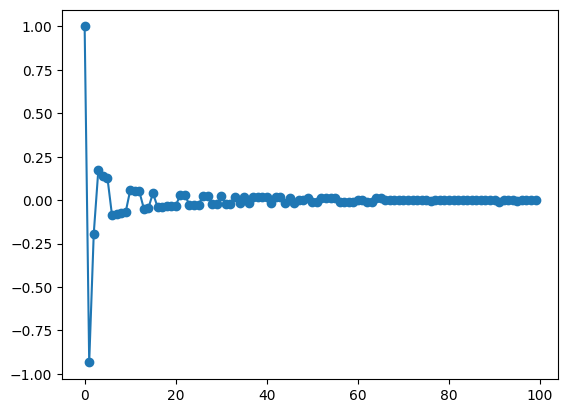

[[0.00436573+0.j]] 106.421844 123.698425
0.9999964 19.981592 19.981531


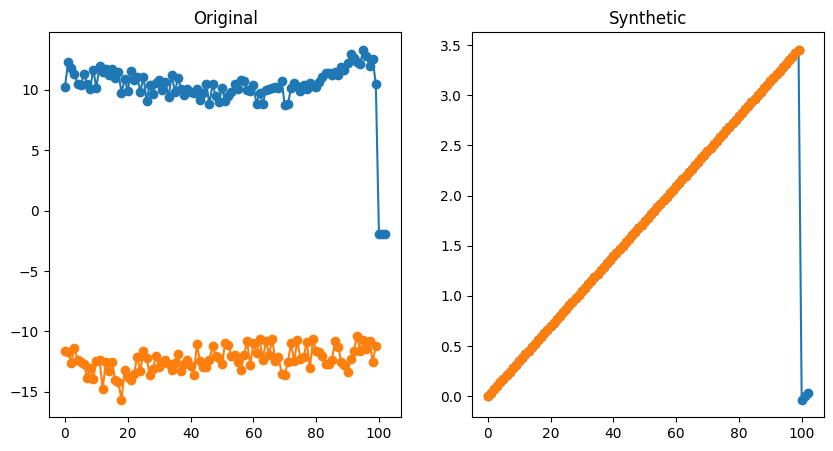

[[0.97673994+0.j]] 21.128696 11.358322
0.9999996 24.406618 21.730558


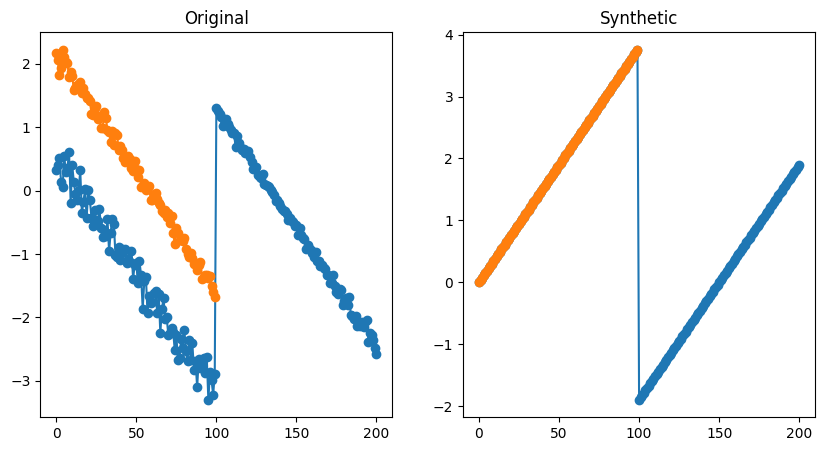

In [101]:

for max_move in [1, C.length_corridors[0]//2]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    N = C.length_corridors[0]
    A = max_move
    X -= X.mean(axis=0, keepdims=True)
    y -= y.mean(axis=0, keepdims=True)

    n = X.shape[0]
    S_XX = X.T@X/n
    S_XY = X.T@y/n
    S_YY = y.T@y/n
    S_YX = y.T@X/n

    a = np.linalg.eig(np.linalg.pinv(S_XX)@S_XY@np.linalg.pinv(S_YY)@S_YX)[1][:,[0]]
    b = np.linalg.eig(np.linalg.pinv(S_YY)@S_YX@np.linalg.pinv(S_XX)@S_XY)[1][:,[0]]
    a /= np.sqrt(a.T@S_XX@a)
    b /= np.sqrt(b.T@S_YY@b)

    a_syn = np.concatenate([np.arange(0,N), np.arange(-A,A+1)]).astype(np.float32)
    b_syn = np.arange(0,N).astype(np.float32)
    a_syn /= np.sqrt(a_syn.T@S_XX@a_syn)
    b_syn /= np.sqrt(b_syn.T@S_YY@b_syn)

    print(a.T@S_XY@b, np.linalg.norm(a), np.linalg.norm(b))
    print(a_syn.T@S_XY@b_syn, np.linalg.norm(a_syn), np.linalg.norm(b_syn))
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].plot(a, marker='o')
    axs[0].plot(b, marker='o')
    axs[0].set_title('Original')
    axs[1].plot(a_syn, marker='o')
    axs[1].plot(b_syn, marker='o')
    axs[1].set_title('Synthetic')
    plt.show()


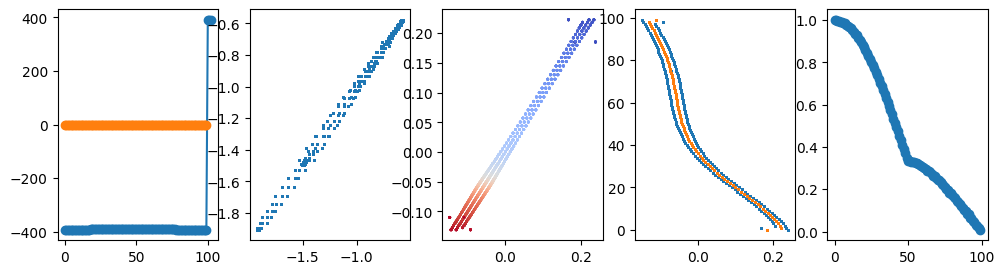

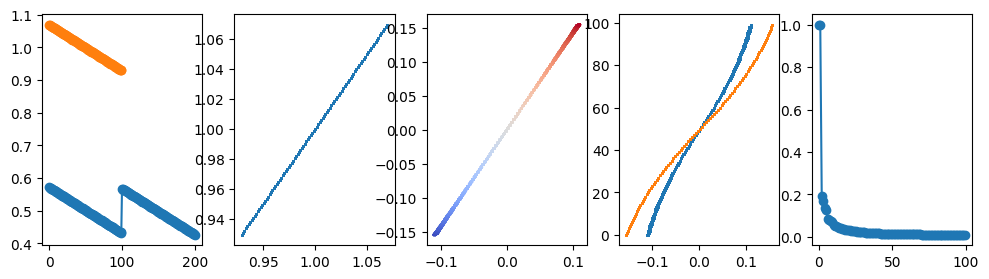

In [19]:
C.length_corridors = [100]
C.print_progress = False
for max_move in [1,C.length_corridors[0]//2]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    X = np.concatenate([X]*10, axis=0)
    y = np.concatenate([y]*10, axis=0)
    action_taken = np.concatenate([action_taken]*10, axis=0)

    X += np.random.randn(*X.shape)*0.0
    y += np.random.randn(*y.shape)*0.0
    labels = y.argmax(1)
    cond = abs(action_taken) <= 1

    n = X.shape[0]
    S_XX = X.T@X/n
    S_XY = X.T@y/n
    S_YY = y.T@y/n
    S_YX = y.T@X/n

    cca = CCA(n_components=2)
    Z_cca, _ = cca.fit_transform(X, y)

    fig, axs = plt.subplots(1, 5, figsize=(12, 3))
    M = matrix_inverse_sqrt(S_XX)@S_XY@matrix_inverse_sqrt(S_YY)
    U, S, V = np.linalg.svd(M)
    axs[0].plot(matrix_inverse_sqrt(S_XX)@U[:,[0]], marker='o')
    axs[0].plot(matrix_inverse_sqrt(S_YY)@V[[0],:].T, marker='o')
    axs[1].scatter(X@matrix_inverse_sqrt(S_XX)@U[:,0], y@matrix_inverse_sqrt(S_YY)@V[0,:], s=1)
    axs[2].scatter(X[cond]@cca.x_rotations_[:,0], y[cond]@cca.y_rotations_[:,0], s=1, c=labels[cond], cmap='coolwarm')
    axs[3].scatter(X[cond]@cca.x_rotations_[:,0], labels[cond], s=1)
    axs[3].scatter(y[cond]@cca.y_rotations_[:,0], labels[cond], s=1)
    axs[4].plot(S, marker='o')
    plt.show()


<Figure size 1000x500 with 0 Axes>

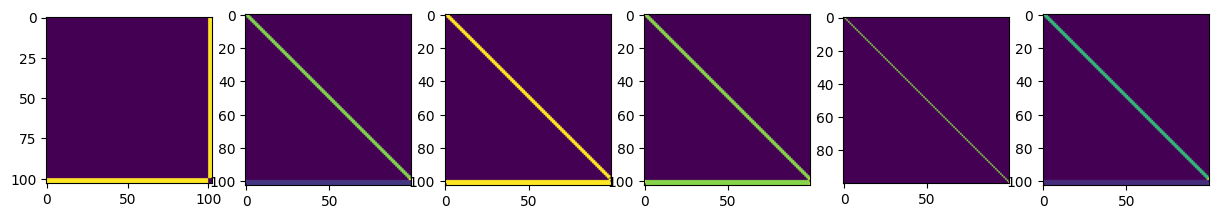

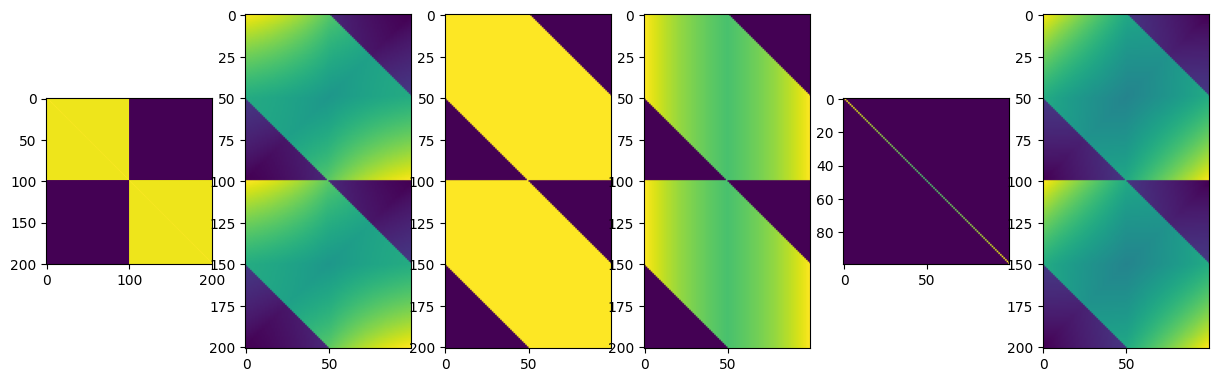

In [31]:
C.length_corridors = [100]
C.print_progress = False
plt.figure(figsize=(10, 5))
for max_move in [1, C.length_corridors[0]//2]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    cond = abs(action_taken) <= 1

    S_XX = X.T@X/X.shape[0]
    S_XY = X.T@y/X.shape[0]
    S_YY = y.T@y/X.shape[0]
    S_YX = y.T@X/X.shape[0]

    U_XX, L_XX, V_XX = np.linalg.svd(S_XX)
    U_XY, L_XY, V_XY = np.linalg.svd(S_XY)
    U_YY, L_YY, V_YY = np.linalg.svd(S_YY)
    U_YX, L_YX, V_YX = np.linalg.svd(S_YX)

    fig, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(U_XX@np.diag(L_XX**(-0.5))@V_XX)
    axs[1].imshow(U_XX@np.diag(L_XX**(-0.5))@V_XX@S_XY)
    axs[2].imshow(S_XY)
    axs[3].imshow(S_XY@U_YY@np.diag(L_YY**(-0.5))@V_YY)
    axs[4].imshow(U_YY@np.diag(L_YY**(-0.5))@V_YY)
    axs[5].imshow(U_XX@np.diag(L_XX**(-0.5))@V_XX@S_XY@U_YY@np.diag(L_YY**(-0.5))@V_YY)
    plt.show()


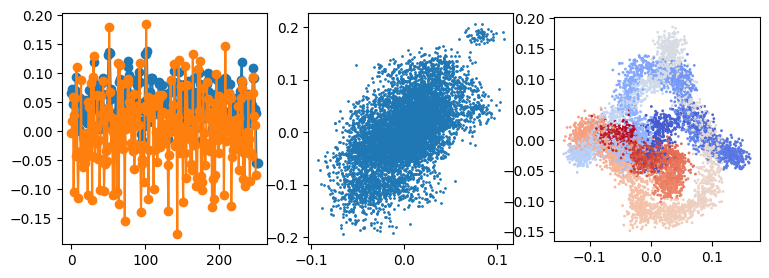

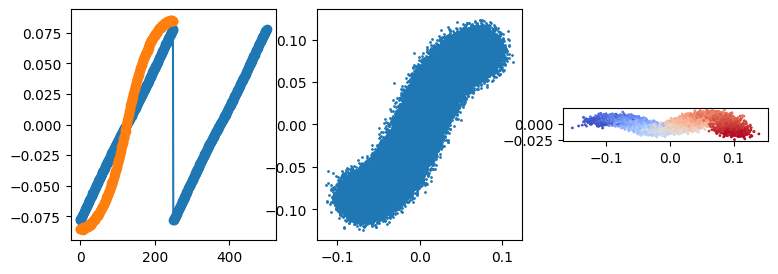

In [120]:
C.length_corridors = [250]
C.print_progress = False
for max_move in [1,125]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    X = np.concatenate([X]*10, axis=0)
    y = np.concatenate([y]*10, axis=0)
    action_taken = np.concatenate([action_taken]*10, axis=0)

    X += np.random.randn(*X.shape)*0.01
    y += np.random.randn(*y.shape)*0.01

    S_XX = np.linalg.pinv(X.T@X)
    S_XY = X.T@y
    S = S_XX@S_XY
    U, L, V = np.linalg.svd(S)

    y_hat = X@S
    y_hat = y_hat[abs(action_taken) <= 1]
    y_hat_pca = PCA(n_components=2).fit_transform(y_hat)
    labels = y.argmax(1)[abs(action_taken) <= 1]

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    axs[0].plot(U[:,0], marker='o')
    axs[0].plot(V[0,:], marker='o')
    axs[1].scatter(X@U[:,0], y@V[0,:], s=1)
    axs[2].scatter(y_hat_pca[:,0], y_hat_pca[:,1], s=1, c=labels, cmap='coolwarm')
    axs[2].set_aspect('equal')
    plt.show()


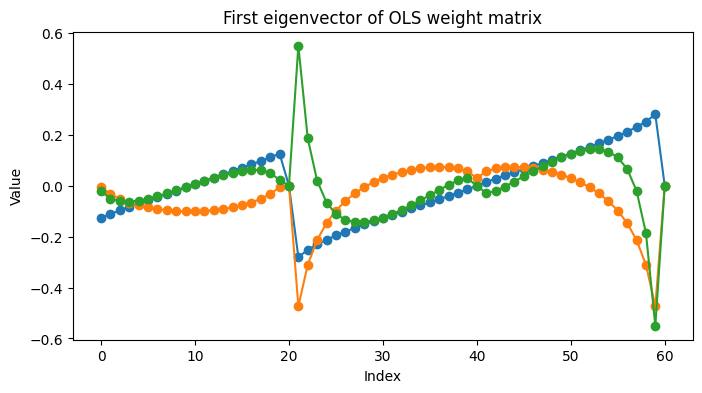

In [14]:
# Calculate OLS weight matrix W = (X^T X)^(-1) X^T y
W_ols = np.linalg.pinv(X.T @ X) @ X.T @ y

# Compute eigenvectors of W_ols (if W_ols is not square, use SVD)
if W_ols.shape[0] == W_ols.shape[1]:
    eigvals, eigvecs = np.linalg.eig(W_ols)
    first_eigvec = eigvecs[:, np.argmax(np.abs(eigvals))]
else:
    # Use SVD for the first left singular vector
    U, S, Vt = np.linalg.svd(W_ols)
    first_eigvec = U[:, :3]

plt.figure(figsize=(8,4))
plt.plot(first_eigvec, marker='o')
plt.title("First eigenvector of OLS weight matrix")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()


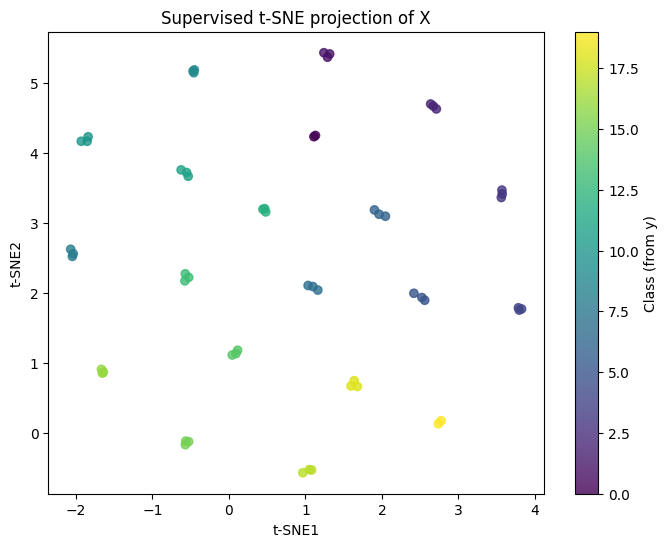

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances

def supervised_tsne(X, y, n_components=2, perplexity=30, random_state=42, label_boost=5.0):
    """
    Supervised t-SNE:
    - Encourages samples with the same label to be closer in the t-SNE space.
    - Implements this by reducing distances between samples of the same class before t-SNE.
    """
    # Encode labels if not already numeric
    if not np.issubdtype(y.dtype, np.number):
        y_enc = LabelEncoder().fit_transform(y)
    else:
        y_enc = y

    # Compute pairwise distances
    D = pairwise_distances(X, metric='euclidean')
    # Modify distances: reduce within-class distances ("label boosting")
    label_matrix = (y_enc[:, None] == y_enc[None, :])
    D_mod = D.copy()
    same_label = label_matrix & (np.eye(D.shape[0]) == 0)
    D_mod[same_label] /= label_boost

    # Fit t-SNE on the custom distance matrix
    tsne = TSNE(n_components=n_components, perplexity=perplexity, metric='precomputed', init='random', random_state=random_state)
    X_tsne = tsne.fit_transform(D_mod)
    return X_tsne

# Prepare y for label use
if y.ndim > 1 and y.shape[1] == 1:
    y_tsne = y.ravel()
elif y.ndim == 1:
    y_tsne = y
else:
    y_tsne = np.argmax(y, axis=1)

# Keep consistent filtering
mask = abs(action_taken) <= 1
X_tsne = X[mask]
y_tsne = y_tsne[mask]

X_le_proj = supervised_tsne(X_tsne, y_tsne, n_components=2, perplexity=30, label_boost=5.0)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_le_proj[:, 0], X_le_proj[:, 1], c=y_tsne, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Class (from y)')
plt.title("Supervised t-SNE projection of X")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.show()


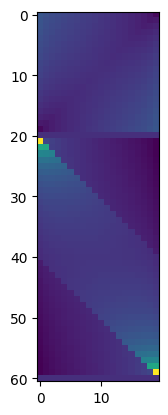

In [16]:
Sigma11 = X.T@X
Sigma31 = X.T@y
plt.imshow(np.linalg.pinv(Sigma11)@Sigma31)

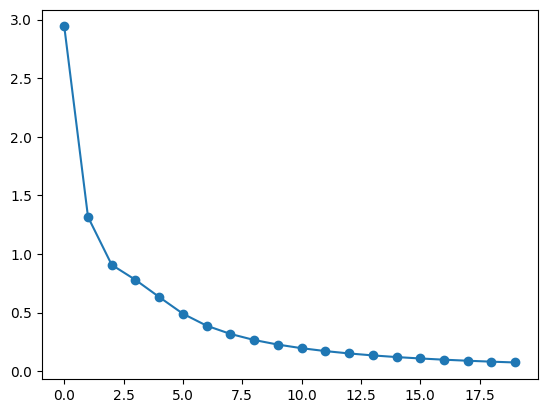

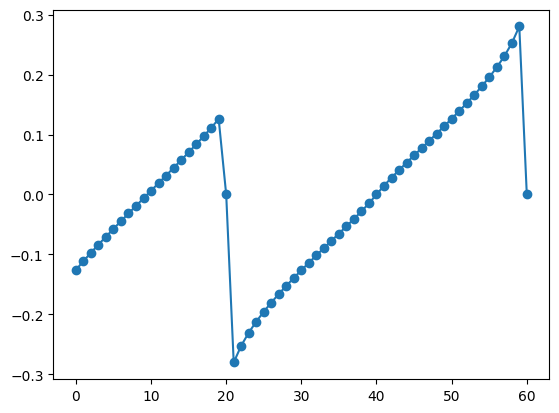

In [17]:
U, S, V = np.linalg.svd(np.linalg.pinv(Sigma11)@Sigma31)
plt.plot(S, marker='o')
plt.show()
plt.plot(U[:,0], marker='o')
plt.show()


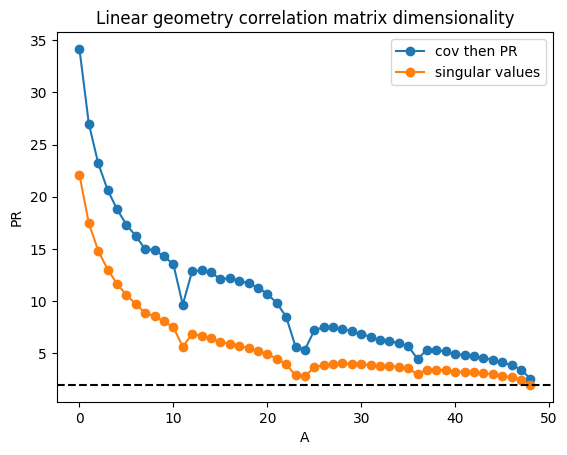

In [18]:
PR_sim_l = []
PR_l = []
C.cyclic_corridors = True
C.print_progress = False
C.length_corridors[0] = 50
L = C.length_corridors[0]
for A in range(1,L):
    C.max_move = A
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)

    Sigma =X.T@y
    U, S, V = np.linalg.svd(Sigma)
    PR_sim_l.append(S.sum()**2/np.sum(S**2))

    Sigma =np.linalg.pinv(X.T@X)@X.T@y
    U, S, V = np.linalg.svd(Sigma)
    PR_l.append(S.sum()**2/np.sum(S**2))
    # plt.plot(S, marker='o')

    
    # Sigma = np.zeros((2*A+1+L,L))
    # a = 2/(2*A+1+L)
    # lamb = np.concatenate([np.ones(A+1)*a, np.ones(L-2*A-1)*(-a/2), np.ones(A)*a])

    # for i in range(1,L):
    #     Sigma[i] = np.roll(lamb, i)
    # Sigma[L:,:] = a/2
    # # plt.imshow(Sigma)
    # # plt.show()
    # U, S, V = np.linalg.svd(Sigma)
    # S = S**2
    # PR_l.append(S.sum()**2/np.sum(S**2))
# plt.show()
plt.plot(PR_l, marker='o', label='cov then PR')
plt.plot(PR_sim_l, marker='o', label='singular values')
plt.legend()
plt.ylabel('PR')
plt.xlabel('A')
plt.axhline(2, c='k', linestyle='--')
# plt.yscale('log')
plt.title(f'Linear geometry correlation matrix dimensionality')
plt.show()


In [19]:
C = Config()

C.seed = 0
C.G = 1
C.linear_net = True
C.corridor_dim = 2
C.learning_rate = 0.001
C.L=5
C.print_progress = True
C.length_corridors = [5]*1
C.hidden_size = 100
C.num_epochs = 1000
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()

C.data_geometry = '2d_euclidean'
C.length_corridors = 10   # grid size LxL
C.max_move = 2
C.action_shape = 'square' # or 'square'
C.one_hot_inputs = True
C.one_hot_actions = True
C.cyclic_corridors = False
X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
print(X.shape)

2D Euclidean grid L=10, action_shape=square, max_move=2
Number of actions: 25, number of samples: 1936
Input dim: 125 (state 100 + action 25)
(1936, 125)


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:04<00:00,  3.09it/s]


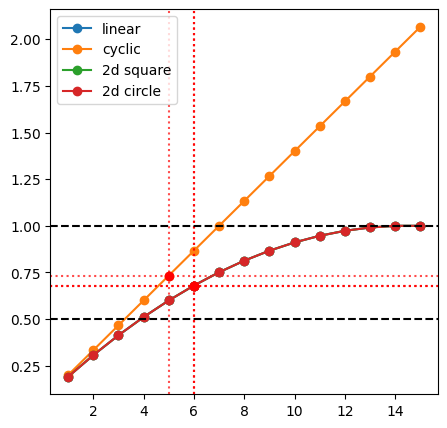

In [20]:
C = Config()
L = 15
C.length_corridors = [L]
fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)
for i, (cyclic_corridors, geometry, action_shape) in enumerate(zip([False,True, False, False], ['euclidean', 'euclidean', '2d_euclidean', '2d_euclidean'], ['square', 'square', 'square', 'circle'])):
    C.cyclic_corridors = cyclic_corridors
    if geometry == '2d_euclidean':
        C.data_geometry = '2d_euclidean'
        C.length_corridors = L
        C.action_shape = action_shape # or 'square'

    else:
        corridor_dim = 1
    A_l = np.arange(1,L+1)
    u1_order_l = []
    PR_l = []
    coverage_l = []
    NC1_l = []
    for A in tqdm(A_l):
        C.max_move = A
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
        # Sigma = np.linalg.pinv(X.T@X)@X.T@y
        # U, S, V = np.linalg.svd(Sigma)
        # u1_order_l.append(get_r_2(X@U[:,:C.corridor_dim]@np.diag(S[:C.corridor_dim]), loc_y))
        # PR_l.append(S.sum()**2/np.sum(S**2))
        # NC1_l.append(calc_NC1(X@U[:,:len(S)]@np.diag(S), y.argmax(1)))
        # plt.imshow((X.T@y)[:L,:L])
        # plt.show()
        coverage_l.append((X.T@y)[:L**C.corridor_dim,:L**C.corridor_dim].mean())
    ax.plot(A_l, coverage_l, marker='o', label=['linear', 'cyclic', '2d square', '2d circle'][i], alpha=1)
    # Find the index where coverage_l is closest to 0.8
    coverage_arr = np.array(coverage_l)
    idx_08 = np.abs(coverage_arr - 0.7).argmin()
    x_08 = A_l[idx_08]
    y_08 = coverage_arr[idx_08]
    # Draw vertical and horizontal lines at this point
    ax.axvline(x_08, color='r', linestyle=':', alpha=0.7)
    ax.axhline(y_08, color='r', linestyle=':', alpha=0.7)
    # Optionally, mark the point
    ax.plot(x_08, y_08, 'ro')
ax.legend()
ax.axhline(0.5, c='k', linestyle='--')
ax.axhline(1, c='k', linestyle='--')
plt.show()
    # fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    # axs[0].plot(u1_order_l, marker='o')
    # axs[0].set_title('u1 order')
    # sc = axs[1].scatter(PR_l, NC1_l, marker='o', c=np.arange(len(PR_l)))
    # axs[1].set_title('PR')
    # plt.colorbar(sc, ax=axs[1], label='Index')
    # axs[1].set_yscale('log')
    # axs[2].plot(coverage_l, marker='o')
    # axs[2].set_title('PR')
    # axs[3].plot(NC1_l, marker='o')
    # axs[3].set_yscale('log')
    # axs[3].set_title('NC1')
    # plt.show()



In [21]:
(X.T@y)[:L**2, :L**2].mean()

0.97850865

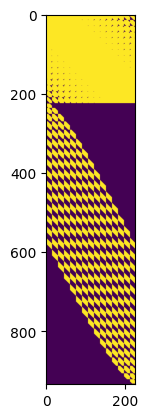

In [22]:
plt.imshow(X.T@y)

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:17<00:00,  1.27s/it]


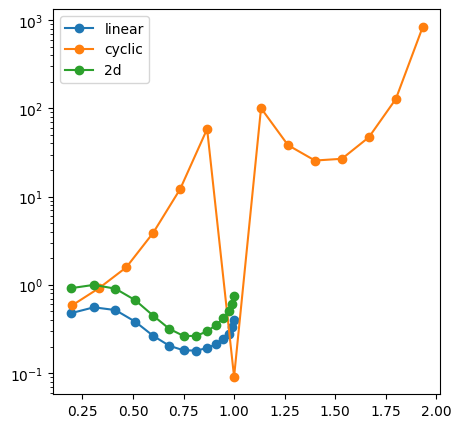

In [23]:
C = Config()
L = 15
C.length_corridors = [L]
fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True)
for i, (cyclic_corridors, geometry) in enumerate(zip([False,True, False], ['euclidean', 'euclidean', '2d_euclidean'])):
    C.cyclic_corridors = cyclic_corridors
    if geometry == '2d_euclidean':
        C.data_geometry = '2d_euclidean'
        C.length_corridors = L
        C.action_shape = 'square' # or 'square'
    else:
        corridor_dim = 1
    A_l = np.arange(1,L)
    u1_order_l = []
    PR_l = []
    coverage_l = []
    NC1_l = []
    for A in tqdm(A_l):
        C.max_move = A
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
        Sigma = np.linalg.pinv(X.T@X)@X.T@y
        U, S, V = np.linalg.svd(Sigma)
        # u1_order_l.append(get_r_2(X@U[:,:C.corridor_dim]@np.diag(S[:C.corridor_dim]), loc_y))
        # PR_l.append(S.sum()**2/np.sum(S**2))
        NC1_l.append(calc_NC1(X@U[:,:len(S)]@np.diag(S), y.argmax(1)))
        # plt.imshow((X.T@y)[:L,:L])
        # plt.show()
        coverage_l.append((X.T@y)[:L**C.corridor_dim,:L**C.corridor_dim].mean())
    ax.plot(coverage_l, NC1_l, marker='o', label=['linear', 'cyclic', '2d'][i], alpha=1)
ax.set_yscale('log')
ax.legend()
# ax.axhline(0.5, c='k', linestyle='--')
# ax.axhline(1, c='k', linestyle='--')
plt.show()
    # fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    # axs[0].plot(u1_order_l, marker='o')
    # axs[0].set_title('u1 order')
    # sc = axs[1].scatter(PR_l, NC1_l, marker='o', c=np.arange(len(PR_l)))
    # axs[1].set_title('PR')
    # plt.colorbar(sc, ax=axs[1], label='Index')
    # axs[1].set_yscale('log')
    # axs[2].plot(coverage_l, marker='o')
    # axs[2].set_title('PR')
    # axs[3].plot(NC1_l, marker='o')
    # axs[3].set_yscale('log')
    # axs[3].set_title('NC1')
    # plt.show()



In [24]:
action_taken

array([[ 0,  0],
       [ 0,  1],
       [ 0,  2],
       ...,
       [ 0, -2],
       [ 0, -1],
       [ 0,  0]])

In [25]:
C.length_corridors

15

In [26]:
X

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [27]:
C.data_geometry

'2d_euclidean'

In [28]:
X

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

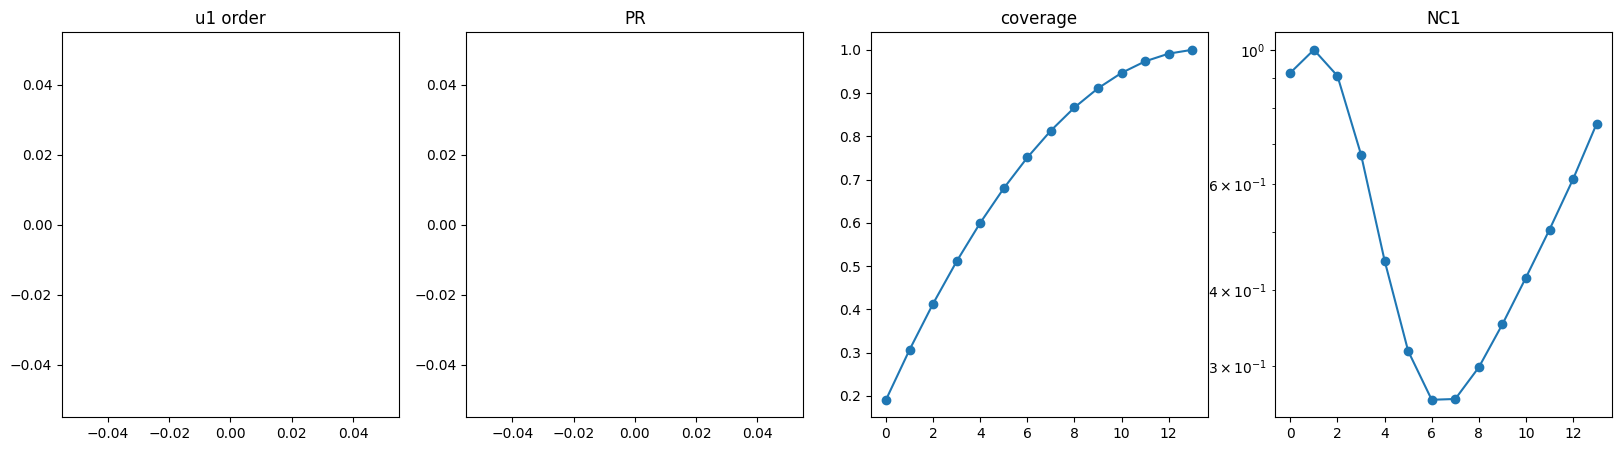

In [29]:

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].plot(u1_order_l, marker='o')
axs[0].set_title('u1 order')
axs[1].plot(PR_l, marker='o')
axs[1].set_title('PR')
axs[2].plot(coverage_l, marker='o')
axs[2].set_title('coverage')
axs[3].plot(NC1_l, marker='o')
axs[3].set_title('NC1')
axs[3].set_yscale('log')
plt.show()

In [30]:
u1_order_l

[]

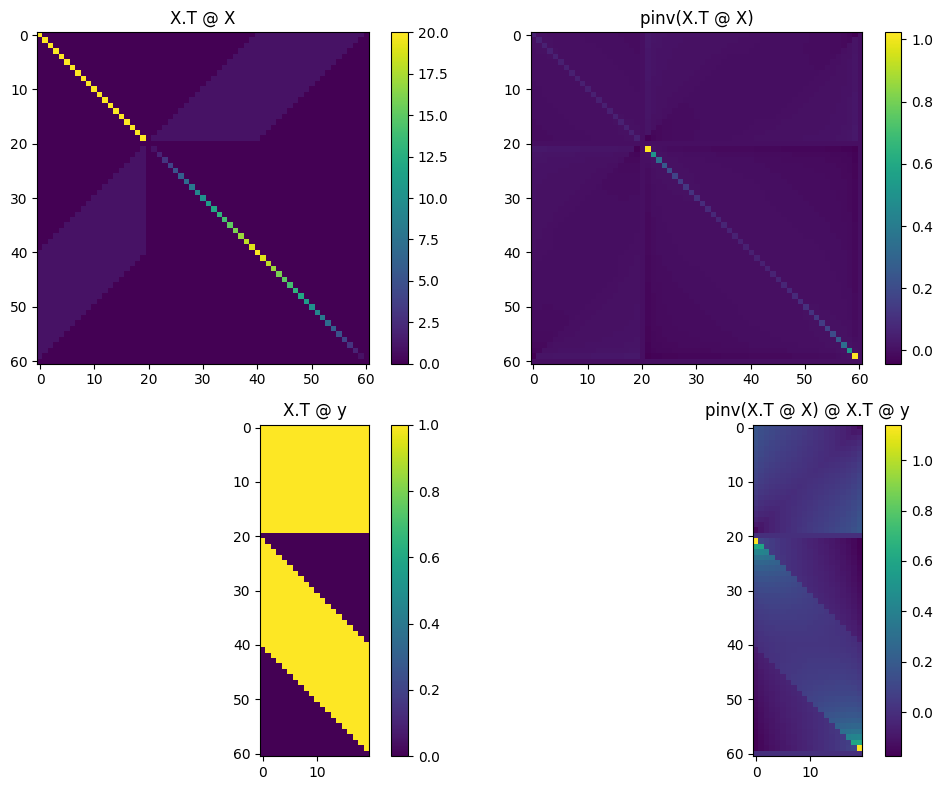

In [31]:
X = X_np
y = y_np
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

im0 = axs[0, 0].imshow(X.T @ X)
axs[0, 0].set_title("X.T @ X")
plt.colorbar(im0, ax=axs[0, 0])

im1 = axs[0, 1].imshow(np.linalg.pinv(X.T @ X))
axs[0, 1].set_title("pinv(X.T @ X)")
plt.colorbar(im1, ax=axs[0, 1])

im2 = axs[1, 0].imshow(X.T @ y)
axs[1, 0].set_title("X.T @ y")
plt.colorbar(im2, ax=axs[1, 0])

im3 = axs[1, 1].imshow(np.linalg.pinv(X.T @ X) @ X.T @ y)
axs[1, 1].set_title("pinv(X.T @ X) @ X.T @ y")
plt.colorbar(im3, ax=axs[1, 1])

plt.tight_layout()
plt.show()

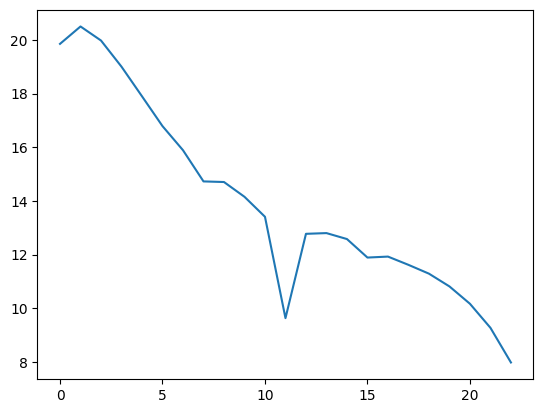

In [32]:
L = 50
PR_l = []
for A in range(1, L//2-1):
    Sigma = np.zeros((2*A+1+L,L))
    a = 2/(2*A+1+L)
    lamb = np.concatenate([np.ones(A+1)*a, np.ones(L-2*A-1)*(-a/2), np.ones(A)*a])

    for i in range(1,L):
        Sigma[i] = np.roll(lamb, i)
    Sigma[L:,:] = a/2
    # plt.imshow(Sigma)
    # plt.show()
    U, S, V = np.linalg.svd(Sigma)
    PR_l.append(S.sum()**2/np.sum(S**2))
    # plt.plot(S)
    # plt.show()
    # plt.plot(U[:,0])
    # plt.show()
plt.plot(PR_l)
plt.show()


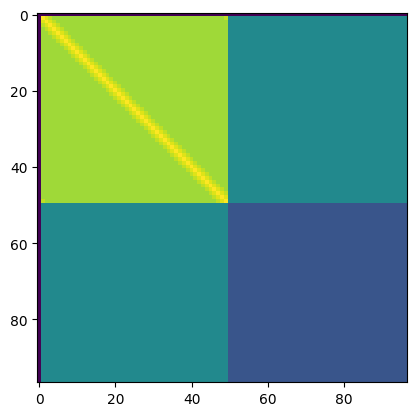

In [33]:
plt.imshow(Sigma@Sigma.T)

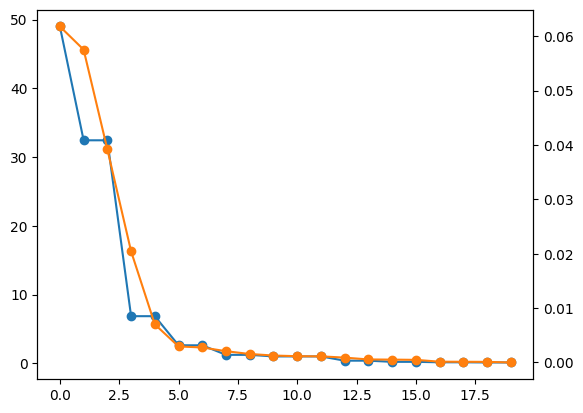

In [34]:
L = 20
C.length_corridors = [L]
A = 3
eigs_l = []
for j in range(L):
    theta = 2*np.pi*j/L
    if j == 0:
        eig = 2*A+1
    else:
        eig = (np.sin((A+0.5)*theta))/np.sin(theta/2)
    eigs_l.append(eig**2)

C.max_move = A
X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)

Sigma =np.linalg.pinv(X.T@X)@X.T@y
U, S, V = np.linalg.svd(Sigma[:L, :L].T@Sigma[:L, :L])
# S = sorted(np.linalg.eig(Sigma[:L, :L])[0])[::-1]

plt.plot(sorted(eigs_l)[::-1], marker='o')
plt.gca().twinx().plot(S, marker='o', c='tab:orange')
plt.show()


In [35]:
import numpy as np
L = 500
C.length_corridors = [L]
C.max_move = A
X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
def block_matrix_pseudoinverse(L, m):
    """
    Compute the Moore-Penrose pseudoinverse of:
        B = [[m*I_L, J_Lxm],
             [J_mxL, L*I_m]]
    where J are all-ones blocks.
    """
    # Identity and ones matrices
    I_L = np.eye(L)
    I_m = np.eye(m)
    J_L = np.ones((L, L))
    J_m = np.ones((m, m))
    J_Lm = np.ones((L, m))
    J_mL = np.ones((m, L))

    # Projectors
    P_L_perp = I_L - J_L / L
    P_m_perp = I_m - J_m / m

    # Construct the projector P_s
    denom = m * L * (m + L)
    top_left = (m**2 / denom) * J_L
    top_right = (m * L / denom) * J_Lm
    bottom_left = (m * L / denom) * J_mL
    bottom_right = (L**2 / denom) * J_m

    P_s = np.block([
        [top_left, top_right],
        [bottom_left, bottom_right]
    ])

    # Build B^+
    # Top-left block: (1/m)*P_L_perp
    top_left_final = (1/m) * P_L_perp
    bottom_right_final = (1/L) * P_m_perp

    B_plus = np.block([
        [top_left_final, np.zeros((L, m))],
        [np.zeros((m, L)), bottom_right_final]
    ]) + (1 / (m + L)) * P_s

    return B_plus

# Example usage:
m = 2*A+1
B_plus = block_matrix_pseudoinverse(L, m)

# Verify with numpy pinv
# Construct B
I_L = np.eye(L)
I_m = np.eye(m)
J_Lm = np.ones((L, m))
J_mL = np.ones((m, L))

B = np.block([
    [m * I_L, J_Lm],
    [J_mL, L * I_m]
])

# Compare with numpy's pseudo-inverse
B_pinv_numpy = np.linalg.pinv(B)
plt.imshow(B_plus)
plt.colorbar()
plt.show()
plt.imshow(np.linalg.pinv(X.T@X))
plt.colorbar()

: 

: 

In [ ]:
plt.imshow(np.linalg.pinv(X)@y)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2)
im1 = ax1.imshow(Sigma[:L, :L])
im2 = ax2.imshow(B)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

In [ ]:
import numpy as np

m = A

# Construct first row
c = np.concatenate([np.ones(m+1), np.zeros(L-2*m-1), np.ones(m)])
# Build circulant matrix
from scipy.linalg import circulant
B = circulant(c)

# Compute AA^T
M = B @ B.T

# Eigen-decomposition
w, v = np.linalg.eigh(M)  # sorted ascending
print("Eigenvalues:", w)

# Theoretical spectrum
theta = 2*np.pi*np.arange(L)/L
lam = np.sin((m+0.5)*theta)/np.sin(theta/2)
lam[0] = 2*m + 1   # fix division by zero
mu = lam**2
print("Theoretical:", np.sort(mu))
plt.plot(np.sort(mu)[::-1], marker='o')
plt.plot(w[::-1], marker='o', c='tab:orange')
plt.show()


In [ ]:
Sigma = np.zeros((L,L))
a = 2/(2*A+1+L)
lamb = np.concatenate([np.ones(A+1)*a, np.ones(L-2*A-1)*(-a/2), np.ones(A)*a])

for i in range(0,L):
    Sigma[i] = np.roll(lamb, i)
# plt.imshow(Sigma)
# plt.show()
S = sorted(np.linalg.eig(Sigma)[0])[::-1]
plt.plot(S, marker='o')

In [ ]:
plt.imshow(Sigma)

In [ ]:
np.unique(np.round(np.linalg.pinv(X.T @ X),5))

In [ ]:
np.unique(np.round(np.linalg.pinv(X.T @ X) @ X.T @ y,5))

In [ ]:
m =  2*C.max_move+1
L = C.length_corridors[0]
1/(L+m)

In [ ]:
L/(L+2*m)

In [ ]:
indices = np.lexsort((loc_y, corridor))
# indices = indices[action_taken[indices]==0]
fig, axs = plt.subplots(2, 3, figsize=(9, 6))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    ax.imshow(var[indices][:, indices], cmap='viridis')
    ax.set_title(f'{var_name} distance matrix')
    ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
pca = PCA().fit(h_np)
if not C.bias:
    W_effective = get_effective_W_from_model_dict(final_weights).cpu().numpy()
    W_PR = calc_PR(W_effective)
else:
    W_PR = 0
hidden_pr = calc_PR(hidden)
# pca_corridors = [PCA() for i in range(n_corridors)]
# [p.fit(hidden[corridor==i]) for i, p in enumerate(pca_corridors)]
# alignment = np.mean([[cosine_similarity(pca_corridors[i].components_[0], pca_corridors[j].components_[0]) for j in
#                       range(n_corridors) if j!=i] for i in range(n_corridors)])
alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
order = get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y)
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(10, 10))

markers = list(mpl.markers.MarkerStyle.markers.keys())[2:]
# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative EVR')
ax1.set_title(f'alignment = {alignment:.2f} --- order = {order:.2f} --- W PR = {W_PR:.2f} --- hidden PR = {hidden_pr:.2f}')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        for n in range(n_corridors):
            s = ax.scatter(X_reduced[corridor==n, i], X_reduced[corridor==n, i+1], c=c[corridor==n], cmap='coolwarm', alpha=0.7, marker=markers[n])
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}')
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
stop

In [ ]:
import torch.nn as nn

# Assume X and y are torch tensors
# y is one-hot, so convert to class indices
y_labels = y.argmax(dim=1)

# Define a linear classifier
linear_clf = nn.Linear(X.shape[1], y.shape[1], bias=False)
optimizer = torch.optim.Adam(linear_clf.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

# Training loop
n_epochs = 10000
W_l = []
loss_l = []
for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    logits = linear_clf(X)
    loss = criterion(logits, y_labels)
    loss.backward()
    optimizer.step()
    loss_l.append(loss.item())
    if epoch % (n_epochs//100) == 0:
        W_l.append(linear_clf.weight.detach().clone())


# Compute accuracy
with torch.no_grad():
    preds = linear_clf(X).argmax(dim=1)
    accuracy = (preds == y_labels).float().mean().item()
print(f"Linear classifier accuracy: {accuracy:.4f}")

plt.plot(loss_l)
plt.yscale('log')
plt.show()


plt.imshow(W_l[-1])


In [ ]:
print(calc_PR(W_l[-1].numpy()))

In [ ]:
W_shallow = linear_clf.weight.detach().clone().numpy().T
W_deep = get_effective_W_from_model_dict(final_weights).numpy()

print(multiclass_functional_margin(W_shallow, X_np, y_np, reducer=np.min))
print(multiclass_functional_margin(W_deep, X_np, y_np, reducer=np.min))

print('PR ratio:', calc_PR(W_deep)/calc_PR(W_shallow))

In [ ]:
L_l = np.arange(3,50)
A_l = []
L_loc_l = []
dim_l = []
N_l = []
N_const_l = []
ratio_AL_l = []
for L in tqdm(L_l):
    for A in range(1,L):
        C = Config()
        C.length_corridors = [L]*1
        C.max_move = A
        X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)

        dim_l.append(X.shape[1]*y.shape[1])
        N_l.append(X.shape[0])
        N_const_l.append(X.shape[0]*(L-1))
        ratio_AL_l.append(A/L)
        A_l.append(A)
        L_loc_l.append(L)

plt.scatter(dim_l, N_l, marker='o', c=ratio_AL_l)
plt.colorbar()
plt.plot([0, max(dim_l+N_l)], [0, max(dim_l+N_l)], linestyle='--', c='k', alpha=0.5)

In [ ]:
plt.scatter([L*(2*A+1)-A*(A+1) for L, A in zip(L_loc_l, A_l)], N_l, c=N_l, marker='o')

In [ ]:
import matplotlib.colors as mcolors

ratio_dim_N = [n/d for d,n in zip(dim_l, N_const_l)]
sc = plt.scatter(L_loc_l, A_l, marker='o', c=ratio_dim_N, norm=mcolors.LogNorm())
plt.plot([0, max(L_loc_l)], [0, max(L_loc_l)/2], linestyle='--', c='k', alpha=0.5)
plt.plot([0, max(L_loc_l)], [0, max(L_loc_l)*0.618], linestyle='--', c='r', alpha=0.5)
plt.xlabel('L')
plt.ylabel('A')
plt.colorbar(sc)

In [ ]:
from utils import *


W = get_effective_W_from_model_dict(final_weights)
print(get_state_dict_norm({'W':W}))
# W = normalize_W_l([W], 11)[0]

U, S, V = np.linalg.svd(W)

# plt.plot(S, marker='o')

l=plt.plot(W, marker='o')


In [ ]:
from torch import softmax, sigmoid

W = get_effective_W_from_model_dict(final_weights)
W = normalize_W_l([W], 11)[0]
classes = y.argmax(1)
scores = X@W
print(scores.shape, classes.shape)
class_i = 1
l = plt.scatter(scores[classes==class_i, class_i], sigmoid(scores[classes==class_i, class_i]), c='g', label='0', marker='o')
l = plt.scatter(scores[classes!=class_i, class_i], sigmoid(scores[classes!=class_i, class_i]), c='r', label='1', marker='x', alpha=0.1)
plt.xlabel('score')
plt.ylabel('sigmoid(score)')
plt.ylim(-0.1, 1.1)
plt.title(f'Sigmoid of scores for classifier {class_i} on all samples')
plt.show()

classifier = np.arange(C.length_corridors[0])
scores = X@W
print(scores.shape, classes.shape)
sample_i = np.where(classes==class_i)[0][scores[classes==class_i, class_i].argmin()]
plt.scatter(scores[sample_i,classifier==class_i], softmax(scores[sample_i,:], axis=0)[classifier==class_i], c='g', label='0', marker='o')
plt.scatter(scores[sample_i,classifier!=class_i], softmax(scores[sample_i,:], axis=0)[classifier!=class_i], c='r', label='1', marker='x', alpha=0.1)
plt.xlabel('score')
plt.ylabel('softmax(scores)')
plt.title(f'Softmax of scores for single {class_i} sample on all classifiers')
plt.show()

plt.scatter(sigmoid(scores[sample_i,classifier==class_i]), softmax(scores[sample_i,:], axis=0)[classifier==class_i], c='g', label='0', marker='o')
plt.scatter(sigmoid(scores[sample_i,classifier!=class_i]), softmax(scores[sample_i,:], axis=0)[classifier!=class_i], c='r', label='1', marker='x', alpha=0.1)
plt.xlabel('sigmoid(score)')
plt.ylabel('softmax(scores)')
plt.title(f'Softmax of scores for single {class_i} sample on all classifiers')
plt.xlim(-0.1, 1.1)
plt.show()

In [ ]:
markers = np.array(['o', 'x', '*'])
colors = np.array(['g', 'r', 'b'])
c1 = 0
c2 = 2
for i in range(3):
    plt.scatter(scores[classes==i,c1], scores[classes==i,c2], c=colors[i], marker=markers[i], label=f'class {i+1}')
plt.plot([-10, 10], [-10, 10], 'k--', label='y=x')  # Diagonal line with slope 1 and intercept 0
plt.legend()
plt.xlabel('classifier 1')
plt.ylabel('classifier 2')
plt.title(f'Scores of classifiers {c1+1} and {c2+1} on all samples')
plt.grid()
plt.axis('equal')
plt.show()

In [ ]:
classes

In [ ]:
import torch
def compute_hessian(W, X_np, y_np):
    # Convert W (numpy) to torch tensor and set requires_grad=True
    W_torch = torch.tensor(W, dtype=torch.float32, requires_grad=True)
    X_torch = torch.tensor(X_np, dtype=torch.float32)
    y_torch = torch.tensor(y_np, dtype=torch.float32)


    def ce_loss(W_flat):
        # Reshape W_flat to original W shape
        W_mat = W_flat.view(W.shape)
        logits = X_torch @ W_mat
        return torch.nn.CrossEntropyLoss()(logits, y_torch)

    W_flat = W_torch.flatten()
    hessian = torch.autograd.functional.hessian(ce_loss, W_flat)

    return hessian


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

U, S, V = torch.linalg.svd(W)
axs[0].plot(S)
axs[0].set_yscale('log')
axs[0].set_title('Eigenvalues')
axs[1].imshow(W.cpu().numpy().T)
axs[1].set_title('Weight Matrix')
plt.show()

In [ ]:
W_pert = W.clone()

for i in tqdm(range(10000)):
    norm_W_pert = get_state_dict_norm({'W':W_pert})
    hessian = compute_hessian(W_pert, X, y)
    eigs, eigs_v = torch.linalg.eig(hessian)
    pert = torch.real(eigs_v[:, eigs.real<0].mean(axis=1))*(norm_W_pert/100)

    pert = pert.reshape(W.shape)

    W_pert = W_pert + pert
    accuracy = ((X@W_pert).argmax(1)==y.argmax(1)).float().mean()
    if accuracy < 1.:
        break

print(accuracy)

plt.imshow(W_pert.cpu().numpy().T)
plt.show()

In [ ]:
W = normalize_W_l([W], 10000)[0]
hessian = compute_hessian(W, X, y)
eigs, eigs_v = torch.linalg.eig(hessian)
hessian_pert = compute_hessian(W_pert, X, y)
eigs_pert, eigs_v_pert = torch.linalg.eig(hessian_pert)
plt.plot(abs(eigs.real), label='original')
# plt.plot(abs(eigs_pert.real), label='perturbed')
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
U, S, V = torch.linalg.svd(W)
U_pert, S_pert, V_pert = torch.linalg.svd(W_pert)
plt.plot(S, marker='o', label='original')
plt.plot(S_pert, marker='o', label='perturbed')
plt.legend()
plt.yscale('log')

In [ ]:
import torch
import torch.nn.functional as F

def compute_hessian(
    W_l: list[torch.Tensor],
    X: torch.Tensor,
    y: torch.Tensor,
    loss_type: str = 'CE'
) -> torch.Tensor:
    """
    Calculates the Hessian matrix of the loss with respect to all parameters (weights)
    of a deep linear network. Supports Cross-Entropy and Mean Squared Error loss.

    Args:
        W_l (list[torch.Tensor]): A list of weight matrices for each layer.
                                    These tensors will have their `requires_grad`
                                    attribute set to True internally if not already.
        X (torch.Tensor): Input tensor for the network. Shape: (batch_size, input_dim).
        y (torch.Tensor): True labels (target) for the loss calculation.
                          - For 'cross_entropy': Shape (batch_size,) for class indices
                            or (batch_size, num_classes) for one-hot.
                          - For 'mse': Shape must match the output `logits` shape,
                            typically (batch_size, output_dim).
        loss_type (str): The type of loss to use. Can be 'cross_entropy' or 'mse'.
                         Defaults to 'cross_entropy'.

    Returns:
        torch.Tensor: The 2D Hessian matrix.
                      Dimensions: (total_num_parameters, total_num_parameters).
    """
    if not W_l:
        raise ValueError("W_l cannot be an empty list. Please provide at least one weight matrix.")

    # Create a list of parameters that require gradients.
    # We clone and detach existing tensors to ensure they are leaves in the computational graph
    # and we can set requires_grad=True without modifying user's original input tensors in place.
    # This also handles cases where W_l contains `nn.Parameter` which already `requires_grad=True`.
    params_for_grad = [W.clone().detach().requires_grad_(True).T if not W.requires_grad else W for W in W_l]

    # --- 1. Forward pass of the deep linear network ---
    # Initialize the input for the first layer
    Z = X
    # Iterate through each weight matrix to perform sequential matrix multiplications
    for W_param in params_for_grad:
        Z = Z @ W_param

    # The final output Z represents the raw logits (or final linear output for MSE)
    logits = Z

    # --- 2. Calculate the Loss ---
    if loss_type == 'CE':
        # Ensure y is in the correct format (class indices) for F.cross_entropy.
        # If y is one-hot encoded (e.g., shape (batch_size, num_classes)),
        # convert it to class indices (e.g., shape (batch_size,)).
        if y.dim() > 1 and y.shape[1] > 1:
            y_labels = torch.argmax(y, dim=1)
        else:
            # If y is already class indices or (batch_size, 1), ensure it's (batch_size,)
            y_labels = y.squeeze()

        # F.cross_entropy expects logits of shape (N, C) and target labels of shape (N).
        # N is batch size, C is number of classes.
        if logits.dim() != 2:
            raise ValueError(
                f"Logits tensor has unexpected shape {logits.shape} for Cross-Entropy. "
                "Expected (batch_size, num_classes). "
                "Ensure the last weight matrix produces outputs for all classes."
            )
        loss = F.cross_entropy(logits, y_labels)

    elif loss_type == 'MSE':
        # For MSE, y should typically have the same shape as logits.
        if logits.shape != y.shape:
            raise ValueError(
                f"For MSE loss, logits shape {logits.shape} and target shape {y.shape} must match."
            )
        loss = F.mse_loss(logits, y)
    else:
        raise ValueError(f"Unsupported loss type: {loss_type}. Choose 'cross_entropy' or 'mse'.")

    # --- 3. Compute the total number of scalar parameters ---
    # This determines the size of the square Hessian matrix.
    num_params = sum(W.numel() for W in params_for_grad)
    # Initialize an empty square matrix to store the Hessian.
    hessian_matrix = torch.zeros((num_params, num_params), dtype=X.dtype, device=X.device)

    # --- 4. Compute the first-order gradient of the loss ---
    # We compute the gradient of the scalar loss with respect to all parameter tensors.
    # `create_graph=True` is crucial here because we need to compute gradients of these gradients later.
    # `allow_unused=True` handles cases where a parameter might not be part of the graph (though unlikely for linear net).
    first_grads_tuple = torch.autograd.grad(loss, params_for_grad, create_graph=True, allow_unused=True)

    # Flatten the first-order gradients from a tuple of tensors into a single 1D tensor.
    # If a gradient is None (meaning the parameter doesn't affect the loss), we fill with zeros.
    flat_first_grads_list = []
    for g, W_param in zip(first_grads_tuple, params_for_grad):
        if g is not None:
            flat_first_grads_list.append(g.reshape(-1))
        else:
            # This warning indicates a parameter was not used in the loss calculation.
            print(f"Warning: Gradient for a parameter of shape {W_param.shape} was None. Filling with zeros.")
            flat_first_grads_list.append(torch.zeros_like(W_param.view(-1)))

    flat_first_grads = torch.cat(flat_first_grads_list)

    # --- 5. Compute the Hessian row by row ---
    # Iterate over each component (scalar) of the flattened first-order gradient vector.
    for i, grad_i in enumerate(flat_first_grads):
        # Compute the gradient of this specific component (grad_i)
        # with respect to all parameter tensors again. This forms one row of the Hessian.
        # `retain_graph=True` is essential because each iteration re-uses the computational
        # graph built during the loss calculation and first_grads computation.
        # If `retain_graph=False` (default), the graph would be freed after the first backward pass.
        second_grads_tuple = torch.autograd.grad(grad_i, params_for_grad, retain_graph=True, allow_unused=True)

        # Flatten these second-order gradients and concatenate them to form a single row for the Hessian.
        flat_second_grads_row_list = []
        for sg, W_param in zip(second_grads_tuple, params_for_grad):
            if sg is not None:
                flat_second_grads_row_list.append(sg.reshape(-1))
            else:
                # Similar handling as for first_grads if a second gradient is None.
                flat_second_grads_row_list.append(torch.zeros_like(W_param.view(-1)))

        hessian_row = torch.cat(flat_second_grads_row_list)
        # Assign the computed row to the Hessian matrix.
        hessian_matrix[i, :] = hessian_row

    return hessian_matrix



In [ ]:


def normalize_W_l(W_l, norm=100):
    if isinstance(W_l[0], torch.Tensor):
        theta = torch.concatenate([W.flatten() for W in W_l])
        factor = torch.linalg.norm(theta)/norm
        return [W/factor for W in W_l]
    else:
        theta = np.concatenate([W.flatten() for W in W_l])
        factor = np.linalg.norm(theta)/norm
    return [W/factor for W in W_l]

In [ ]:
losses = []
W_l = [W.T for W in final_weights.values()]
W_effective = reduce(lambda x, y: x@y, W_l)
print(F.cross_entropy(X@W_effective, y).item())
print(torch.linalg.norm(torch.concatenate([W.flatten() for W in W_l])).item())
norms = np.linspace(1, 5.914, 1000)
for norm in tqdm(norms):
    W_l = normalize_W_l(W_l, norm)
    W_effective = reduce(lambda x, y: x@y, W_l)
    losses.append(F.cross_entropy(X@W_effective, y).item())
plt.plot(norms, losses)
plt.yscale('log')
plt.show()


In [ ]:
W_l = [W for W in final_weights.values()]
# W_l = normalize_W_l(W_l, 1)
H = compute_hessian(W_l, X, y, 'CE')

In [ ]:
eigs, eigs_v = torch.linalg.eig(H)
eigs = eigs.cpu().detach().numpy()
eigs_v = eigs_v.cpu().detach().numpy()

In [ ]:
from utils import compute_gradient

grad = compute_gradient(W_l, X, y, 'CE')

In [ ]:
g = grad.cpu().detach().numpy()
H_v = np.real(eigs_v[:, abs(eigs).argmax()])
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
plt.plot([cosine_similarity(g, v) for v in np.real(eigs_v)])
plt.gca().twinx().plot(np.abs(eigs), color='red')
plt.show()
plt.scatter(g, H_v)


In [ ]:
eigs, eigs_v = torch.linalg.eig(H)

In [ ]:
from utils import compute_gradient

grad = compute_gradient(W_l, X, y)

In [ ]:
g = grad.cpu().detach().numpy()
H_v = np.real(eigs_v[:, abs(eigs).argmax()].cpu().detach().numpy())
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
plt.plot([cosine_similarity(g, v) for v in np.real(eigs_v.cpu().detach().numpy())])
plt.gca().twinx().plot(np.abs(eigs), color='red')
plt.show()
plt.scatter(g, H_v)


In [ ]:
def normalize_W_l(W_l, norm=100):
    theta = torch.concatenate([W.flatten() for W in W_l])
    factor = torch.linalg.norm(theta)/norm
    return [W/factor for W in W_l]
W_l = [W for W in final_weights.values()]
# W_l = normalize_W_l(W_l, 1)
H = compute_hessian(W_l, X, y, 'MSE')
eigs1, eigs_v = torch.linalg.eig(H)
W_l = [W for W in initial_weights.values()]
# W_l = normalize_W_l(W_l, 1)
H = compute_hessian(W_l, X, y, 'MSE')
eigs2, eigs_v = torch.linalg.eig(H)
plt.plot(np.real(eigs1), label='final')
plt.plot(np.real(eigs2), label='initial')
plt.legend()
plt.show()


In [ ]:
from utils import compute_hessian, compute_gradient 

W_l = [W for W in final_weights.values()]
W_l = nnormalize_W_l(W_l, 1)
H = compute_hessian(W_l, X, y, loss_fn='CE')

In [ ]:
eigs, eigs_v = torch.linalg.eig(H)

In [ ]:
from utils import compute_gradient

grad = compute_gradient(W_l, X, y)

In [ ]:
g = grad.cpu().detach().numpy()
H_v = np.real(eigs_v[:, abs(eigs).argmax()].cpu().detach().numpy())
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
plt.plot([cosine_similarity(g, v) for v in np.real(eigs_v.cpu().detach().numpy())])
plt.gca().twinx().plot(np.abs(eigs), color='red')
plt.show()
plt.scatter(g, H_v)


In [ ]:
import torch
import torch.nn.functional as F

def forward_pass(X, W_l):
    """Forward pass through a sequence of linear layers without non-linearities."""
    h = X
    for W in W_l:
        h = h @ W.T
    return h  # logits

def compute_loss(y_hat, y):
    return F.mse_loss(y_hat, y)

def flatten_params(W_l):
    """Flatten all weight matrices into a single vector."""
    return torch.cat([w.reshape(-1) for w in W_l])

def unflatten_params(flat_params, shapes):
    """Restore list of weight matrices from a flat parameter vector."""
    W_l = []
    idx = 0
    for shape in shapes:
        numel = torch.prod(torch.tensor(shape)).item()
        W_l.append(flat_params[idx:idx+numel].reshape(shape))
        idx += numel
    return W_l

def compute_full_hessian(X, y, W_l):
    """Compute the full Hessian of the loss w.r.t. all weights in W_l."""
    shapes = [w.shape for w in W_l]
    flat_params = flatten_params(W_l).detach().clone().requires_grad_(True)

    # Reconstruct W_l from flat_params for autograd
    def loss_fn(p):
        W_reconstructed = unflatten_params(p, shapes)
        logits = forward_pass(X, W_reconstructed)
        loss = compute_loss(logits, y)
        return loss

    loss = loss_fn(flat_params)
    grad = torch.autograd.grad(loss, flat_params, create_graph=True)[0]

    H_rows = []
    for i in range(grad.numel()):
        grad2 = torch.autograd.grad(grad[i], flat_params, retain_graph=True)[0]
        H_rows.append(grad2)

    H = torch.stack(H_rows, dim=0)  # Shape: (n_params, n_params)
    return H

In [ ]:
# H = compute_full_hessian(X, y, list(final_weights.values())).detach().cpu().numpy()

In [ ]:
# eigs, eigs_v = np.linalg.eig(H)

In [ ]:
# plt.plot(eigs, marker='o', ls='',markersize=3)
# plt.axhline(0, color='black', ls='--', alpha=.5)
# plt.xscale('log')
# plt.show()

In [ ]:
# W = np.linalg.pinv(X_np.T@X_np)@X_np.T@y_np
# y_hat = X_np@w
# print(np.mean((y_hat - y_np)**2)/y_np.var())
# def factorize_matrix(M, N):
#     D1, D2 = M.shape
#     # Compute full SVD
#     U, S, Vt = np.linalg.svd(M, full_matrices=False)
#     rank = np.sum(S > 1e-10)  # numerical rank

#     # Generate random orthogonal matrix
#     Q = np.random.randn(N, N)
#     Q, _ = np.linalg.qr(Q)

#     S = np.diag(S)
#     # Create random factorization that still reconstructs M
#     S_pad = np.concatenate([S, np.zeros([D2, N-D2])], 1)
#     A = U @ np.sqrt(S_pad) @ Q
#     S_pad = np.concatenate([S, np.zeros([N-D2, D2])], 0)
#     B = Q.T @ np.sqrt(S_pad) @ Vt
#     return A, B

# A, B = factorize_matrix(W, C.hidden_size)
# W_l = [torch.tensor(A.T, dtype=torch.float32), torch.tensor(B.T, dtype=torch.float32)]
# H = compute_full_hessian(X, y, W_l).detach().cpu().numpy()
# eigs, eigs_v = np.linalg.eig(H)
# plt.plot(eigs, marker='o', ls='',markersize=3)
# plt.axhline(0, color='black', ls='--', alpha=.5)
# plt.xscale('log')
# plt.show()

In [ ]:
# L = C.length_corridors[0]
# L_start = -L/2; L_end = L/2
# A = C.max_move

# w = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
# W_in = w@np.ones((1,C.hidden_size))/100

# X_new = X_np@W_in
# W_out = np.linalg.pinv(X_new.T@X_new)@X_new.T@y_np

# W_l = [torch.tensor(W_in.T, dtype=torch.float32), torch.tensor(W_out.T, dtype=torch.float32)]
# H = compute_full_hessian(X, y, W_l).detach().cpu().numpy()
# eigs, eigs_v = np.linalg.eig(H)
# plt.plot(eigs, marker='o', ls='',markersize=3)
# plt.axhline(0, color='black', ls='--', alpha=.5)
# plt.xscale('log')
# plt.show()

In [ ]:
# hiddens = [h[-1] for h in hidden_l]
# pr_l = []
# for hidden in hiddens:
#     cov_matrix = np.cov(hidden.T)
#     # Get eigenvalues
#     eigenvalues = np.linalg.eigvalsh(cov_matrix)
#     eigenvalues = np.sort(eigenvalues)[::-1]  # Sort in descending order
#     # Calculate cumulative explained variance
#     cum_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
#     # Calculate participation ratio
#     pr = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)
#     pr_l.append(pr)

# plt.plot(pr_l)
# # plt.yscale('log')

In [ ]:
import numpy as np

def get_AB(X, w1, w2, b, n):
    # Step 1: Compute target matrix
    Y = (X @ w1) @ w2 + np.ones((X.shape[0], 1)) @ b  # (m, c)

    # Step 2: Compute effective Z = X^\dagger Y
    X_dagger = np.linalg.pinv(X)                     # (d, m)
    Z = X_dagger @ Y                                 # (d, c)

    # Step 3: Low-rank SVD factorization
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    n_max = min(n, min(Z.shape))  # Don't take more components than available
    U_n = np.zeros((U.shape[0], n))  # Initialize with zeros
    S_n = np.zeros((n, n))  # Initialize diagonal matrix with zeros
    Vn = np.zeros((n, Vt.shape[1]))  # Initialize with zeros
    
    # Fill available components
    U_n[:, :n_max] = U[:, :n_max]
    S_n[:n_max, :n_max] = np.diag(np.sqrt(S[:n_max]))
    Vn[:n_max, :] = Vt[:n_max, :]

    A = U_n @ S_n                  # (d, n)
    B = S_n @ Vn                   # (n, c)
    return A, B


In [ ]:
L = C.length_corridors[0]
L_start = -L/2; L_end = L/2
A = C.max_move
n_model = 1
Win = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
Wout = 1/n_model*np.linspace(L_start,L_end, L)[None,:]**n_model
b = -1/(n_model+1)*np.linspace(L_start,L_end, L)[None, :]**(n_model+1)

print('Accuracy of tailored solution: ', ((X_np@Win@Wout+b).argmax(1)==(y_np.argmax(1))).mean())

In [ ]:
A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)

print('Accuracy of tailored solution: ', ((X_np@A@B).argmax(1)==(y_np.argmax(1))).mean())

In [ ]:
plt.imshow((A@B).T)

In [ ]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(15,5))
ax1.plot(Win); ax1.set_title('Win functional')
ax2.plot(Wout.T); ax2.set_title('Wout functional')
ax3.plot(b.T); ax3.set_title('Wout effective bias functional')

In [ ]:
import numpy as np

# Inputs
W = Wout      # shape (d, n)
b = b      # shape (1, n)

# Compute pseudoinverse
X_dagger = np.linalg.pinv(X_np)               # shape (d, m)
one_m = np.ones((X_np.shape[0], 1))           # shape (m, 1)

# Compute correction term
delta_A = (X_dagger @ one_m) @ b           # shape (d, n)

# Final A
A = W + delta_A


In [ ]:
pca = PCA().fit(hidden)
Win = reduce(np.matmul, [W.cpu().numpy().T for k, W in final_weights.items() if 'weight' in k][:-1])
Wout = final_weights['output_layer.weight'].cpu().numpy()
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(15,5))
ax1.plot(Win@pca.components_[[0]].T); ax1.set_title('Win proj')
ax2.plot(Wout@pca.components_[[0]].T); ax2.set_title('Wout proj')
ax3.plot(Wout@pca.mean_); ax3.set_title('Wout effective bias proj')

In [ ]:
# plt.plot(final_weights['output_layer.bias'].cpu().numpy())

In [ ]:

output_weights = final_weights['output_layer.weight'].cpu().detach().numpy()
n_corridors = len(C.length_corridors)
pca = PCA(); pca_corridors = [PCA() for _ in range(n_corridors)];
[p.fit(hidden[corridor == i]) for i, p in enumerate(pca_corridors)]
pca.fit(hidden)
h_transformed = pca.transform(h_np)
h_transformed_l = [p.transform(h_np[corridor == i]) for i, p in enumerate(pca_corridors)]
criterion = C.loss_fn
pca_accuracy_l = []
pca_explained_var_l = []
pca_loss_l = []
order_l = []
n_pcs = np.arange(1, min(min([min(h_transformed_l[i].shape) for i in range(n_corridors)]), 100))
for n in n_pcs:
    # h_reconstructed = pca.inverse_transform(h_transformed)
    h_reconstructed = h_transformed[:,:n] @ pca.components_[:n] + pca.mean_
    y_hat_pca = (h_reconstructed @ output_weights.T)
    # print(f'accuracy of first {n} PCs: {(y_hat_first_pc == y.argmax(1).cpu().detach().numpy()).mean()}')
    pca_accuracy_l.append((y_hat_pca.argmax(1) == y_np.argmax(1)).mean())
    pca_explained_var_l.append(pca.explained_variance_ratio_[:n].sum())
    pca_loss_l.append(criterion(torch.tensor(y_hat_pca), y.cpu()).item())
    order = [get_r_2(h[:, [n-1]], loc_y[corridor == i]) for i, h in enumerate(h_transformed_l)]
    order_l.append(np.mean(order))

In [ ]:
fig, ax1 = plt.subplots()
plt.plot(n_pcs, pca_accuracy_l, label='accuracy', marker='o')
plt.plot(n_pcs, pca_explained_var_l, label='explained variance', marker='o')
plt.plot(n_pcs, order_l, label='PC order', marker='o')
plt.axhline(1, color='gray', ls='--', alpha=0.7)
ax2 = ax1.twinx()
ax2.set_ylabel('loss')
ax2.plot(n_pcs, pca_loss_l, 'r', label='loss', ls='--', alpha=0.7)
ax2.set_yscale('log')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
plt.xlabel('number of PCs')
# plt.xscale('log')
plt.tight_layout()
plt.show()

In [ ]:

sigma11 = np.sum([xi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
U33,S, V11 = np.linalg.svd(sigma31)
V11 = V11.T

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(sigma11); axs[0].set_title('$\Sigma_{11}$')
axs[1].imshow(sigma31); axs[1].set_title('$\Sigma_{31}$')
axs[2].imshow(U33); axs[2].set_title('$U_{33}$')
axs[3].imshow(V11); axs[3].set_title('$V_{11}$')

In [ ]:
h = X_np@V11[:,:2]
plt.scatter(h[:,0], h[:,1], c=loc_y)
fig, axs = plt.subplots(1, 10, figsize=(20, 10))
for i in range(10):
    axs[i].imshow(V11[:,:i+1]@np.diag(S[:i+1])@U33[:,:i+1].T)

In [ ]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
result = W_l[0].T
for W in W_l[1:]:
    result = np.matmul(result, W.T)

# Sigma = np.corrcoef(X_np.T, y_np.T)
# Sigma31 = Sigma[X_np.shape[1]:, :X_np.shape[1]]
# Sigma11 = Sigma[:X_np.shape[1], :X_np.shape[1]]
Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
# ax1.imshow(W32@W21)
im = ax1.imshow(result.T, cmap='viridis')
plt.colorbar(im, ax=ax1)
ax1.set_ylabel('output')
ax1.set_xlabel('input')
ax1.set_title(r'$\prod_{i,j} W_{ij}$', fontsize=50)
im = ax2.imshow(Sigma31@np.linalg.pinv(Sigma11), cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('$\Sigma_{31}\Sigma_{11}^{-1}$', fontsize=50)
ax2.set_xlabel('X dim')
ax2.set_ylabel('y dim')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def factorize_matrix(M, N=None):
    D1, D2 = M.shape
    # Compute full SVD
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    rank = np.sum(S > 1e-10)  # numerical rank

    if N is None:
        N = min(D1,D2)  # default N to rank(M)
    
    # Take the first N singular values
    U_N = U[:, :N] 
    S_N = np.diag(S[:N])
    Vt_N = Vt[:N, :]

    # Generate random orthogonal matrix
    Q = np.random.randn(N, N)
    Q, _ = np.linalg.qr(Q)
    
    # Create random factorization that still reconstructs M
    A = U_N @ np.sqrt(S_N) @ Q
    B = Q.T @ np.sqrt(S_N) @ Vt_N
    return A, B

# Example:
M = Sigma31@np.linalg.pinv(Sigma11)
A, B = factorize_matrix(M, N=None)
M_reconstructed = A @ B
plt.imshow(M_reconstructed)
plt.title(f'Error in reconstruction = {np.linalg.norm(M_reconstructed-M):.4f}')
plt.show()

In [ ]:
h_syntetic = X_np @ B.T
pca = PCA().fit(h_syntetic)
X_reduced = pca.transform(h_syntetic)

lamb_h = PCA().fit(hidden).explained_variance_
lamb_h_syn = PCA().fit(h_syntetic).explained_variance_
lamb_out = PCA().fit(outputs).explained_variance_
lamb_tag = PCA().fit(X_np @ sigma31.T).explained_variance_
lamb_X = PCA().fit(X_np).explained_variance_
lamb_y = PCA().fit(y_np).explained_variance_
print(f'PR model hidden = {lamb_h.sum() ** 2 / (lamb_h ** 2).sum()}')
print(f'PR synthetic hidden = {lamb_h_syn.sum() ** 2 / (lamb_h_syn ** 2).sum()}')
print(f'PR model output = {lamb_out.sum() ** 2 / (lamb_out ** 2).sum()}')
print(f'PR sigma31 output = {lamb_tag.sum() ** 2 / (lamb_tag ** 2).sum()}')
print(f'PR X = {lamb_X.sum() ** 2 / (lamb_X ** 2).sum()}')
print(f'PR y = {lamb_y.sum() ** 2 / (lamb_y ** 2).sum()}')


In [ ]:
from sklearn.svm import LinearSVC
# Train hard-margin SVM (C is large => hard margin)
clf = LinearSVC(fit_intercept=True, C=1e-9)
clf.fit(X_np, y_np.argmax(1))
w_SVM = clf.coef_
print(clf.score(X_np, y_np.argmax(1)))
print(((X_np@w_SVM.T + clf.intercept_[None,:]).argmax(1)==y_np.argmax(1)).mean())

In [ ]:
from functools import reduce
W_effective = reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()])
Corr_matrix = Sigma31@np.linalg.pinv(Sigma11)
clf = LogisticRegression(multi_class='multinomial', penalty=None)
clf.fit(X_np, y_np.argmax(1))
print(f'Model accuracy = {((X_np@W_effective).argmax(1)==y_np.argmax(1)).mean():.2f}')
print(f'Corr matrix accuracy = {((X_np@Corr_matrix.T).argmax(1)==y_np.argmax(1)).mean():.2f}')
print(f'Logistic regression accuracy = {accuracy_score(clf.predict(X_np), y_np.argmax(1)):.2f}')



In [ ]:
L = C.length_corridors[0]
L_start = -L/2; L_end = L/2
A = C.max_move
n_model = 1
Win = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
Wout = 1/n_model*np.linspace(L_start,L_end, L)[None,:]**n_model
b = -1/(n_model+1)*np.linspace(L_start,L_end, L)[None, :]**(n_model+1)

print('Accuracy of tailored solution: ', ((X_np@Win@Wout+b).argmax(1)==(y_np.argmax(1))).mean())

A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)
W_synthetic = (A@B).T
print('Accuracy of tailored solution: ', ((X_np@A@B).argmax(1)==(y_np.argmax(1))).mean())

In [ ]:
W_dict = {
    'W_model':reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()]).T,
    'W_synthetic':W_synthetic,
    # 'W_logistic':LogisticRegression(multi_class='multinomial', fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
    # 'W_regression':LinearRegression(fit_intercept=False).fit(X_np, y_np).coef_,
    # 'W_logistic_noreg':LogisticRegression(multi_class='multinomial', penalty=None, fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
    'W_correlation':Sigma31@np.linalg.pinv(Sigma11),
    'W_decomposition':(V11[:,:2]@np.diag(S[:2])@U33[:,:2].T).T,
}
# for k,v in W_dict.items():
#     W_dict[k] = v/v.max()
fig, axs = plt.subplots(1, len(W_dict), figsize=(8*len(W_dict),5))
for ax, (W_name, W) in zip(axs, W_dict.items()):
    # if W_name == 'W_loremote
    #  = W
    ax.imshow(W, cmap='coolwarm')
    lamb = PCA().fit(X_np@W.T).explained_variance_
    PRWX = lamb.sum() ** 2 / (lamb ** 2).sum()
    lamb = PCA().fit(W).explained_variance_
    PR = lamb.sum() ** 2 / (lamb ** 2).sum()
    ax.set_title(f'{W_name} --- acc={accuracy_score((X_np@W.T).argmax(1), y_np.argmax(1)):.2f} --- PR W={PR:.2f} --- PR WX={PRWX:.2f} --- W rank: {np.linalg.matrix_rank(W, tol=np.sqrt(lamb[0])*(1/W.shape[0]))}')
    ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
    ax.grid(False)

In [ ]:
import torch
import torch.nn.functional as F

def compute_hessian(x, W_l, target):
    """
    Compute the Hessian of MSE loss w.r.t. the flattened parameters.

    Args:
        W_l (list of torch.Tensor): List of weight matrices (no bias).
        x (torch.Tensor): Input tensor of shape (batch_size, in_features).
        target (torch.Tensor): Target tensor of shape (batch_size, out_features).

    Returns:
        torch.Tensor: 2D Hessian matrix of shape (num_params, num_params).
    """
    # Make sure weights require gradients
    W_l = [torch.tensor(w).float().requires_grad_(True) for w in W_l]

    # Forward pass through layers
    out = x
    for W in W_l:
        out = out @ W.T  # Linear layer without bias

    # Loss (mean squared error)
    if isinstance(C.loss_fn, nn.CrossEntropyLoss):
        loss = F.cross_entropy(F.softmax(out, dim=1), target)
    else:
        loss = F.mse_loss(out, target)

    # Flatten parameters
    params_vector = torch.cat([w.reshape(-1) for w in W_l])

    # Compute gradients (first-order)
    grads = torch.autograd.grad(loss, W_l, create_graph=True)
    grads_vector = torch.cat([g.reshape(-1) for g in grads])

    num_params = params_vector.numel()
    hessian = torch.zeros(num_params, num_params)

    for i in range(num_params):
        grad2rd = torch.autograd.grad(grads_vector[i], W_l, retain_graph=True)
        grad2rd_vector = torch.cat([g.contiguous().reshape(-1) for g in grad2rd])
        hessian[i] = grad2rd_vector

    return hessian

device = X.device
hessians = {}
plt.figure(figsize=(20,8))
ax = plt.gca()
for i, (W_name, W) in enumerate(W_dict.items()):
    print(f"Computing Hessian for {W_name}...")
    H = compute_hessian(X, [torch.tensor(W).to(device)], y)
    hessians[W_name] = H
    
    # Print some properties of the Hessian
    eigvals = np.linalg.eigvals(H)
    print(f"Hessian eigenvalues - min: {np.min(np.real(eigvals)):.2e}, max: {np.max(np.real(eigvals)):.2e}")
    
    # Plot eigenvalues
    plt.subplot(1, len(W_dict), i+1, sharey=ax)
    eigvals = np.sort(np.real(eigvals))[::-1]
    plt.plot(eigvals, 'o-')
    plt.yscale('log')
    plt.title(f'{W_name} H eigs, sum={abs(np.real(eigvals)).sum():.4f}')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Plot eigenvalues for each W matrix
plt.figure(figsize=(20,8))
ax  = plt.gca()
for i, (W_name, W) in enumerate(W_dict.items()):
    # Calculate eigenvalues 
    W_norm = W/np.linalg.norm(W)
    eigenvals = np.linalg.eigvals(W_norm @ W_norm.T)
    eigenvals = np.sort(np.abs(eigenvals))[::-1]
    
    plt.subplot(1, len(W_dict), i+1, sharey=ax)
    plt.plot(eigenvals, 'o-')
    plt.yscale('log')
    plt.title(f'{W_name} Eigenvalues')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Calculate cross-entropy loss for each W matrix
losses = {}
for W_name, W in W_dict.items():
    # Get predictions
    W_norm = W/np.linalg.norm(W)
    logits = X_np @ W_norm.T
    
    # Apply softmax
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    
    # Calculate cross entropy loss
    if isinstance(C.loss_fn, nn.CrossEntropyLoss):
        loss = -np.mean(np.sum(y_np * np.log(probs + 1e-10), axis=1))
    else:
        loss = np.mean((logits-y_np)**2)
    losses[W_name] = loss
    print(f'Loss for {W_name}: {loss:.4f}, accuracy: {(logits.argmax(1)==y_np.argmax(1)).mean()}')
# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(losses.keys(), losses.values())
plt.xticks(rotation=45)
plt.ylabel('Loss')
plt.title('Loss by Weight Matrix Type')
plt.tight_layout()
plt.yscale('log')
plt.show()



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def deep_factorization(W, L, D=None, lr=1e-3, steps=100):
    D_in, D_out = W.shape
    D = D if D else D_in  # assuming square for simplicity
    factors = nn.ParameterList()

    # Initialize factors
    factors.append(nn.Parameter(torch.randn(D_in, D)))
    for _ in range(L - 2):
        factors.append(nn.Parameter(torch.randn(D, D)))
    factors.append(nn.Parameter(torch.randn(D, D_out)))

    optimizer = optim.Adam(factors, lr=lr)
    W_target = torch.tensor(W, dtype=torch.float32)

    for step in range(steps):
        optimizer.zero_grad()
        W_approx = factors[0]
        for i in range(1, L+1):
            W_approx = W_approx @ factors[i]
        loss = ((W_approx - W_target) ** 2).mean()
        loss.backward()
        optimizer.step()
    
    return [f.detach().numpy().T for f in factors]


In [ ]:
# Create figure with subplots for each W matrix
fig, axs = plt.subplots(2, len(W_dict), figsize=(6*len(W_dict), 8))
axs = axs.T
for i, (W_name, W) in tqdm(enumerate(W_dict.items())):
    # Factorize matrix and get synthetic hidden states
    # if W_name == 'W_model':
    #     U, S, V = np.linalg.svd(W)
    #     W = U[:,:2]@np.diag(S[:2])@V[:2,:]
    A, B = factorize_matrix(W, N=None)
    W_l = [A, B]
    print(f"Computing Hessian for {W_name}...")
    # H = compute_hessian(X, [torch.tensor(w).to(device) for w in W_l], y)
    # eigvals = abs(np.linalg.eigvals(H))
    print(np.linalg.norm(reduce(np.matmul, [W.T for W in W_l]).T-W))
    h_synthetic = X_np @ reduce(np.matmul, [W.T for W in W_l[:-1]])
    
    # Fit PCA
    pca = PCA().fit(h_synthetic)
    X_reduced = pca.transform(h_synthetic)
    
    # Plot explained variance ratio
    axs[i,0].plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    PR = pca.explained_variance_.sum()**2/(pca.explained_variance_**2).sum()
    axs[i,0].set_xlabel('Number of Components')
    axs[i,0].set_ylabel('Cumulative Explained Variance')
    axs[i,0].set_title(f'{W_name}: PR = {PR:.2f} --- max H eig: {eigvals.max():.2e} --- sum H eigs {eigvals.sum():.2f}')
    
    # Plot first two PCs colored by location
    s = axs[i,1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=loc_y, 
                        cmap='coolwarm', alpha=0.7)
    axs[i,1].set_xlabel('PC1')
    axs[i,1].set_ylabel('PC2')
    axs[i,1].set_title(f'{W_name} - First 2 PCs')
    fig.colorbar(s, ax=axs[i,1])
    axs[i,1].axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
stop

In [ ]:
plt.plot(abs(eigs))
plt.yscale('log')

In [ ]:
from tqdm import tqdm
lamb_h_l = []
for h in tqdm(hidden_l[::10]):
    lamb_h_l.append(PCA().fit(h[-1]).explained_variance_)

In [ ]:
plt.plot([lamb.sum()**2/(lamb**2).sum() for lamb in lamb_h_l])
plt.ylabel('PR of last hidden layer')
plt.xlabel('Epochs')
plt.ylim(0)

In [ ]:
# # Compute participation ratio for a matrix
# def compute_participation_ratio(matrix):
#     eigenvalues = np.linalg.eigvalsh(matrix @ matrix.T)  # Compute eigenvalues of the covariance matrix
#     eigenvalues = eigenvalues[eigenvalues > 1e-10]  # Filter out near-zero eigenvalues for numerical stability
#     pr = (np.sum(eigenvalues) ** 2) / np.sum(eigenvalues ** 2)
#     return pr
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios = {}
# for name, weight in final_weights.items():
#     weight_np = weight.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios[' '.join(name.split('.')[:-1])] = compute_participation_ratio(weight_np)
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios_h = {}
# for i, h in enumerate([X] + hidden_states + [y]):
#     hid_np = h.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios_h[f'hidden_{i+1}'] = compute_participation_ratio(hid_np)
#
# # Plot the participation ratios
# fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
# ax1.plot(participation_ratios.keys(), participation_ratios.values(), color='skyblue')
# ax1.set_ylim(0)
# ax1.set_xticklabels(participation_ratios.keys(), rotation=45, ha='right')
# ax2.plot(participation_ratios_h.keys(), participation_ratios_h.values(), color='orange')
# # ax2.set_xticks(rotation=45, ha='right')
# ax1.set_ylabel('Participation Ratio')
# ax2.set_ylim(0)
# fig.suptitle('Participation Ratio of Weight Matrices and hiddens')
# plt.tight_layout()
# plt.show()

In [ ]:
n_actions = X.shape[1] - sum(C.length_corridors)
a_in_hidden = np.concatenate([np.zeros([n_actions, y.shape[1]]), np.eye(n_actions)],1)
n_states = X.shape[1] - n_actions
s_in_hidden = np.concatenate([np.eye(n_states), np.zeros([n_states, n_actions])],1)
for W in W_l[:-1]:
    a_in_hidden = a_in_hidden @ W.T
    s_in_hidden = s_in_hidden @ W.T

colors = plt.cm.jet(np.linspace(0, 1, a_in_hidden.shape[1]))
for i, color in enumerate(colors):
    plt.plot(np.arange(n_actions), a_in_hidden[:, i], color=color)
plt.xlabel('action')
plt.ylabel('hidden state')
plt.title('Action representation in hidden state, each line is a neuron')
plt.show()


In [ ]:
from utils import get_upper_triangle

d_b = []
d_n = []
for h in tqdm(hidden_l[1::10]):
    h = torch.tensor(h[-1]).to('cuda:2' if torch.cuda.is_available() else 'cpu')
    hidden_centers = torch.stack([h[y[:,i]==1].mean(0) for i in range(y.shape[1])])
    hidden_between_cluster_dists = torch.diag(torch.cdist(hidden_centers, hidden_centers),1).mean().item()
    hidden_within_cluster_dists = torch.tensor([get_upper_triangle(torch.cdist(h[y[:,i]==1], h[y[:,i]==1])).mean() for i in range(y.shape[1])]).mean().item()
    hidden_mean_norm = torch.linalg.norm(h, dim=1).mean().item()
    d_n.append(hidden_within_cluster_dists / hidden_mean_norm)
    d_b.append(hidden_within_cluster_dists / hidden_between_cluster_dists)
print(f'Within cluster distance normalized by between cluster distances: {d_b[-1]:.2f}')
print(f'Within cluster distance normalized by mean hidden norm: {d_n[-1]:.2f}')

plt.plot(d_b, label='between cluster distances')
plt.plot(d_n, label='mean hidden norm')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Distance')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

def compute_hessian(W_l, x, target):
    """
    Compute the Hessian of MSE loss w.r.t. the flattened parameters.

    Args:
        W_l (list of torch.Tensor): List of weight matrices (no bias).
        x (torch.Tensor): Input tensor of shape (batch_size, in_features).
        target (torch.Tensor): Target tensor of shape (batch_size, out_features).

    Returns:
        torch.Tensor: 2D Hessian matrix of shape (num_params, num_params).
    """
    # Make sure weights require gradients
    W_l = [w.clone().detach().requires_grad_(True) for w in W_l]

    # Forward pass through layers
    out = x
    for W in W_l:
        out = out @ W.T  # Linear layer without bias

    # Loss (mean squared error)
    loss = F.mse_loss(out, target)

    # Flatten parameters
    params_vector = torch.cat([w.view(-1) for w in W_l])

    # Compute gradients (first-order)
    grads = torch.autograd.grad(loss, W_l, create_graph=True)
    grads_vector = torch.cat([g.view(-1) for g in grads])

    num_params = params_vector.numel()
    hessian = torch.zeros(num_params, num_params)

    for i in range(num_params):
        grad2rd = torch.autograd.grad(grads_vector[i], W_l, retain_graph=True)
        grad2rd_vector = torch.cat([g.contiguous().view(-1) for g in grad2rd])
        hessian[i] = grad2rd_vector

    return hessian


In [ ]:
num_params = sum([len(W.flatten()) for W in W_l])**2
print(num_params)
if num_params < 1e7:
    weights_for_hess = [W for W in final_weights.values()]
    hessian = compute_hessian(weights_for_hess, X, y)
    L, V = torch.linalg.eig(hessian)
    plt.figure(figsize=(12, 6))
    plt.plot(np.abs(L.numpy()))
    plt.yscale('log')


In [ ]:
sing_vals = [np.linalg.svd(W_l[i])[1] for i in range(C.L)]
plt.figure(figsize=(12, 6))
h=[plt.plot(s) for s in sing_vals]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

matrix_l = [X_np] + [W.T for W in W_l] + [y_np.T]
matrix_names = ['X'] + [f'W_{i}' for i in range(len(W_l))] + ['y']
num_mats = len(matrix_l)
# Step 1: Compute SVDs
svd_results = []
for W in matrix_l:
    U, S, Vt = np.linalg.svd(W)
    svd_results.append({'U': U, 'S': S, 'V': Vt.T})  # Vt.T gives V

# Step 2: Compute correlations between V_l and U_{l+1}
correlations = []
for l in range(num_mats - 1):
    V_l = svd_results[l]['V']  # Output singular vectors of W_l
    U_next = svd_results[l + 1]['U']  # Input singular vectors of W_{l+1}
    S = [svd_results[l]['S'], svd_results[l+1]['S']]
    S = S[np.argmax([min(S[0].shape), min(S[1].shape)])]

    # Compute correlation matrix (dot product between vectors)
    corr_matrix = np.abs(V_l @ U_next)

    # Aggregate correlation (e.g., mean of diagonal as measure)
    corrs = (np.diag(corr_matrix) * S).sum() / S.sum()
    correlations.append(corrs)

# Step 3: Plot
plt.figure(figsize=(8, 5))
plt.plot(range(num_mats-1), correlations, marker='o')
plt.xlabel('Layer (l)')
plt.xticks(range(num_mats-1), [f'{matrix_names[i]} to {matrix_names[i + 1]}' for i in range(num_mats-1)], rotation=45)
plt.ylabel('Mean correlation between V_l and U_{l+1}')
plt.title('Correlation between adjacent layers\' singular vectors')
plt.grid(True)
plt.show()


In [ ]:
h = [plt.plot(svd['S'], label=name) for svd, name in zip(svd_results, matrix_names)]
plt.legend()

In [ ]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
ratios = []
for W in W_l:
    spectral_norm = np.linalg.norm(W, ord=2)
    frobenius_norm = np.linalg.norm(W, ord='fro')
    ratio = spectral_norm / frobenius_norm if frobenius_norm != 0 else np.nan
    ratios.append(ratio)
plt.plot(ratios)

In [ ]:
from scipy.sparse.linalg import svds
from utils import calc_NC1
classes = np.unique(y_np.argmax(1))
NC1_l = []
for h in tqdm(hidden_l):
    NC1_l.append(calc_NC1(h[-1], y_np.argmax(1)))

plt.plot(NC1_l)
plt.title('NC1')
plt.xlabel('Epoch')
plt.yscale('log')

In [ ]:
NC1_l[-1]

In [ ]:
classes = np.unique(y_np.argmax(1))
y_i = y_np.argmax(1)
hidden_centers = [hidden[y_i==c].mean(0) for c in classes]
hidden_centers = np.stack([h/np.linalg.norm(h) for h in hidden_centers])
Wout = final_weights['output_layer.weight'].cpu().numpy()
Wout /= np.linalg.norm(Wout, axis=1)[:, None]

plt.imshow(Wout@hidden_centers.T)
plt.colorbar()
plt.show()
plt.plot(np.diagonal(Wout@hidden_centers.T))

In [ ]:
import torch
import torch.nn.functional as F

def compute_nc_metrics(features, labels, classifier_weights=None, test_features=None):
    """
    Compute NC1–NC4 metrics for neural collapse.

    Arguments:
        features: (N, d) tensor of training features.
        labels: (N,) tensor of class labels in 0...C-1.
        classifier_weights: (C, d) tensor of final layer weights (optional, for NC3).
        test_features: (M, d) tensor of test features (optional, for NC4).

    Returns:
        dict of NC1–NC4 values.
    """
    device = features.device
    features = features.float()
    labels = labels.long()

    classes = torch.unique(labels)
    C = len(classes)
    d = features.shape[1]

    # Compute class means
    class_means = []
    for c in classes:
        class_features = features[labels == c]
        class_mean = class_features.mean(dim=0)
        class_means.append(class_mean)
    class_means = torch.stack(class_means)  # shape (C, d)

    # Compute global mean
    global_mean = features.mean(dim=0)

    # Compute within-class scatter matrix (Sw)
    Sw = 0
    for c in classes:
        class_features = features[labels == c]
        mean_c = class_means[c]
        centered = class_features - mean_c
        Sw += (centered.T @ centered)
    Sw /= features.shape[0]

    # Compute between-class scatter matrix (Sb)
    centered_means = class_means - global_mean
    Sb = centered_means.T @ centered_means / C

    # ---- NC1: Ratio of within-class variance to between-class variance ----
    nc1 = torch.trace(Sw) / torch.trace(Sb)

    # ---- NC2: Cosine similarity matrix of class means ----
    norm_means = F.normalize(class_means, dim=1)
    cosine_matrix = norm_means @ norm_means.T
    off_diag_mask = ~torch.eye(C, dtype=bool, device=device)
    nc2 = cosine_matrix[off_diag_mask].std()

    # ---- NC3: Cosine similarity between classifier weights and class means ----
    if classifier_weights is not None:
        classifier_weights = F.normalize(classifier_weights.float(), dim=1)
        norm_means = F.normalize(class_means, dim=1)
        cos_sim = (classifier_weights * norm_means).sum(dim=1)
        nc3 = 1 - cos_sim.mean()
    else:
        nc3 = None

    # ---- NC4: Compare train and test class mean structures ----
    if test_features is not None:
        test_class_means = []
        for c in classes:
            test_class_features = test_features[labels == c]
            mean = test_class_features.mean(dim=0)
            test_class_means.append(mean)
        test_class_means = torch.stack(test_class_means)
        test_class_means = F.normalize(test_class_means, dim=1)
        norm_means = F.normalize(class_means, dim=1)
        cos_sim = (test_class_means * norm_means).sum(dim=1)
        nc4 = 1 - cos_sim.mean()
    else:
        nc4 = None

    return {
        "NC1": nc1.item(),
        "NC2_std_cosine": nc2.item(),
        "NC3_1-mean_cos": nc3.item() if nc3 is not None else None,
        "NC4_1-mean_cos": nc4.item() if nc4 is not None else None,
    }


In [ ]:
compute_nc_metrics(hidden_states[-1], y.argmax(1), classifier_weights=final_weights['output_layer.weight'], test_features=None)